# Download Dependencies

In [ ]:
# Mount Google drive and import libraries.

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
import shap
import pickle
import json
import warnings
import random
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully!")
print("Google Drive mounted successfully!")

Mounted at /content/drive
All libraries imported successfully!
Google Drive mounted successfully!


# Dataset Mounting, Overview, and Dictionary

In [ ]:
# Mount Dataset from Google Drive

file_path = '/content/drive/MyDrive/CapstoneDataset/hospital_readmission.csv'

print("Loading dataset from Google Drive...")
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

Loading dataset from Google Drive...
Dataset loaded successfully!
Dataset shape: (32300, 10)
Columns: ['age', 'length_of_stay_days', 'num_diagnoses', 'num_medications', 'prev_admissions', 'glucose_level', 'bmi', 'has_diabetes', 'discharge_type', 'readmitted_30days']

First 5 rows:
    age  length_of_stay_days  num_diagnoses  num_medications  prev_admissions  \
0  22.0                 28.0            2.0             13.0              4.0   
1  44.0                 12.0            7.0             11.0              2.0   
2  34.0                 15.0            9.0             16.0              6.0   
3  39.0                 15.0            5.0             16.0              6.0   
4  62.0                 24.0            1.0              6.0              6.0   

   glucose_level   bmi  has_diabetes  discharge_type  readmitted_30days  
0           89.1  48.4           1.0             2.0                  0  
1          254.8  23.9           1.0             0.0                  1  
2        

In [ ]:
# Dataset Overview (Features type, missing value)

print("Dataset Overview")
print(f"Total records: {len(df)}")
print(f"Features: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nDescriptive statistics:\n{df.describe()}")

# Check target variable distribution
target_col = 'readmitted_30days'
if target_col in df.columns:
    print(f"\nTarget column '{target_col}' found!")
    print(f"Readmission rate: {df[target_col].mean():.2%}")
    print(f"Class distribution:\n{df[target_col].value_counts()}")
else:
    print(f"\nWarning: Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")

Dataset Overview
Total records: 32300
Features: ['age', 'length_of_stay_days', 'num_diagnoses', 'num_medications', 'prev_admissions', 'glucose_level', 'bmi', 'has_diabetes', 'discharge_type', 'readmitted_30days']

Missing values:
age                    647
length_of_stay_days    648
num_diagnoses          645
num_medications        646
prev_admissions        646
glucose_level          646
bmi                    646
has_diabetes           647
discharge_type         645
readmitted_30days        0
dtype: int64

Data types:
age                     object
length_of_stay_days    float64
num_diagnoses          float64
num_medications        float64
prev_admissions        float64
glucose_level          float64
bmi                    float64
has_diabetes           float64
discharge_type         float64
readmitted_30days        int64
dtype: object

Descriptive statistics:
       length_of_stay_days  num_diagnoses  num_medications  prev_admissions  \
count         31652.000000   31655.000000     

In [ ]:
# Data dictionary

target_col = 'readmitted_30days'

DICTIONARY = [
    # variable, type, unit, allowed values, description
    ('age',                 'Numeric (continuous)', 'years', '0 to 110',        'Patient age at admission'),
    ('length_of_stay_days', 'Numeric (count)',      'days',  '1 to 365',        'Days from admission to discharge'),
    ('num_diagnoses',       'Numeric (count)',      'count', '1 to 50',         'Number of diagnoses recorded during the stay'),
    ('num_medications',     'Numeric (count)',      'count', '0 to 50',         'Number of medications prescribed'),
    ('prev_admissions',     'Numeric (count)',      'count', '0 to 50',         'Number of previous hospital admissions'),
    ('glucose_level',       'Numeric (continuous)', 'mg/dL', '40 to 600',       'Blood glucose level'),
    ('bmi',                 'Numeric (continuous)', 'kg/m2', '10 to 80',        'Body mass index'),
    ('has_diabetes',        'Binary',               'none',  '0 = no, 1 = yes', 'Diabetes diagnosis'),
    ('discharge_type',      'Categorical (coded)',  'none',  '0, 1, 2',         'Discharge category code'),
    (target_col,            'Binary (target)',      'none',  '0 = no, 1 = yes', 'Readmitted within 30 days of discharge'),
]

data_dictionary = pd.DataFrame(
    DICTIONARY, columns=['variable', 'type', 'unit', 'allowed_values', 'description'])

observed, missing_count = [], []
for v in data_dictionary['variable']:
    if v in df.columns:
        values = pd.to_numeric(df[v].astype(str).str.replace('_err', ''), errors='coerce')
        observed.append(f"{values.min():g} to {values.max():g}")
        missing_count.append(int(df[v].isna().sum()))
    else:
        observed.append('not in dataset')
        missing_count.append(0)

data_dictionary['observed_range'] = observed
data_dictionary['missing'] = missing_count
data_dictionary = data_dictionary[
    ['variable', 'type', 'unit', 'allowed_values', 'observed_range', 'missing', 'description']]

data_dictionary.to_csv('data_dictionary.csv', index=False)
display(data_dictionary)

,variable,type,unit,allowed_values,observed_range,missing,description
0,age,Numeric (continuous),years,0 to 110,18 to 150,647,Patient age at admission
1,length_of_stay_days,Numeric (count),days,1 to 365,1 to 29,648,Days from admission to discharge
2,num_diagnoses,Numeric (count),count,1 to 50,1 to 14,645,Number of diagnoses recorded during the stay
3,num_medications,Numeric (count),count,0 to 50,1 to 200,646,Number of medications prescribed
4,prev_admissions,Numeric (count),count,0 to 50,0 to 9,646,Number of previous hospital admissions
5,glucose_level,Numeric (continuous),mg/dL,40 to 600,60 to 900,646,Blood glucose level
6,bmi,Numeric (continuous),kg/m2,10 to 80,-5 to 50,646,Body mass index
7,has_diabetes,Binary,none,"0 = no, 1 = yes",0 to 1,647,Diabetes diagnosis
8,discharge_type,Categorical (coded),none,"0, 1, 2",0 to 2,645,Discharge category code
9,readmitted_30days,Binary (target),none,"0 = no, 1 = yes",0 to 1,0,Readmitted within 30 days of discharge


# Preprocessing, EDA, and Feature Engineering

In [ ]:
# Data Cleaning (Nulls and Outliers)

print("Check for missing values: ")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
            print(f"  {col}: Filled missing values with median")
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f"  {col}: Filled missing values with mode")

if target_col in df.columns:
    df = df.dropna(subset=[target_col])
    print(f"Removed rows with missing target. New shape: {df.shape}")

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)
    return df

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != target_col:
        df = cap_outliers(df, col)
print(f"\nOutliers capped for {len(numeric_cols)-1} numeric columns")

Check for missing values: 
  age: Filled missing values with mode
  length_of_stay_days: Filled missing values with median
  num_diagnoses: Filled missing values with median
  num_medications: Filled missing values with median
  prev_admissions: Filled missing values with median
  glucose_level: Filled missing values with median
  bmi: Filled missing values with median
  has_diabetes: Filled missing values with median
  discharge_type: Filled missing values with median
Removed rows with missing target. New shape: (32300, 10)

Outliers capped for 8 numeric columns


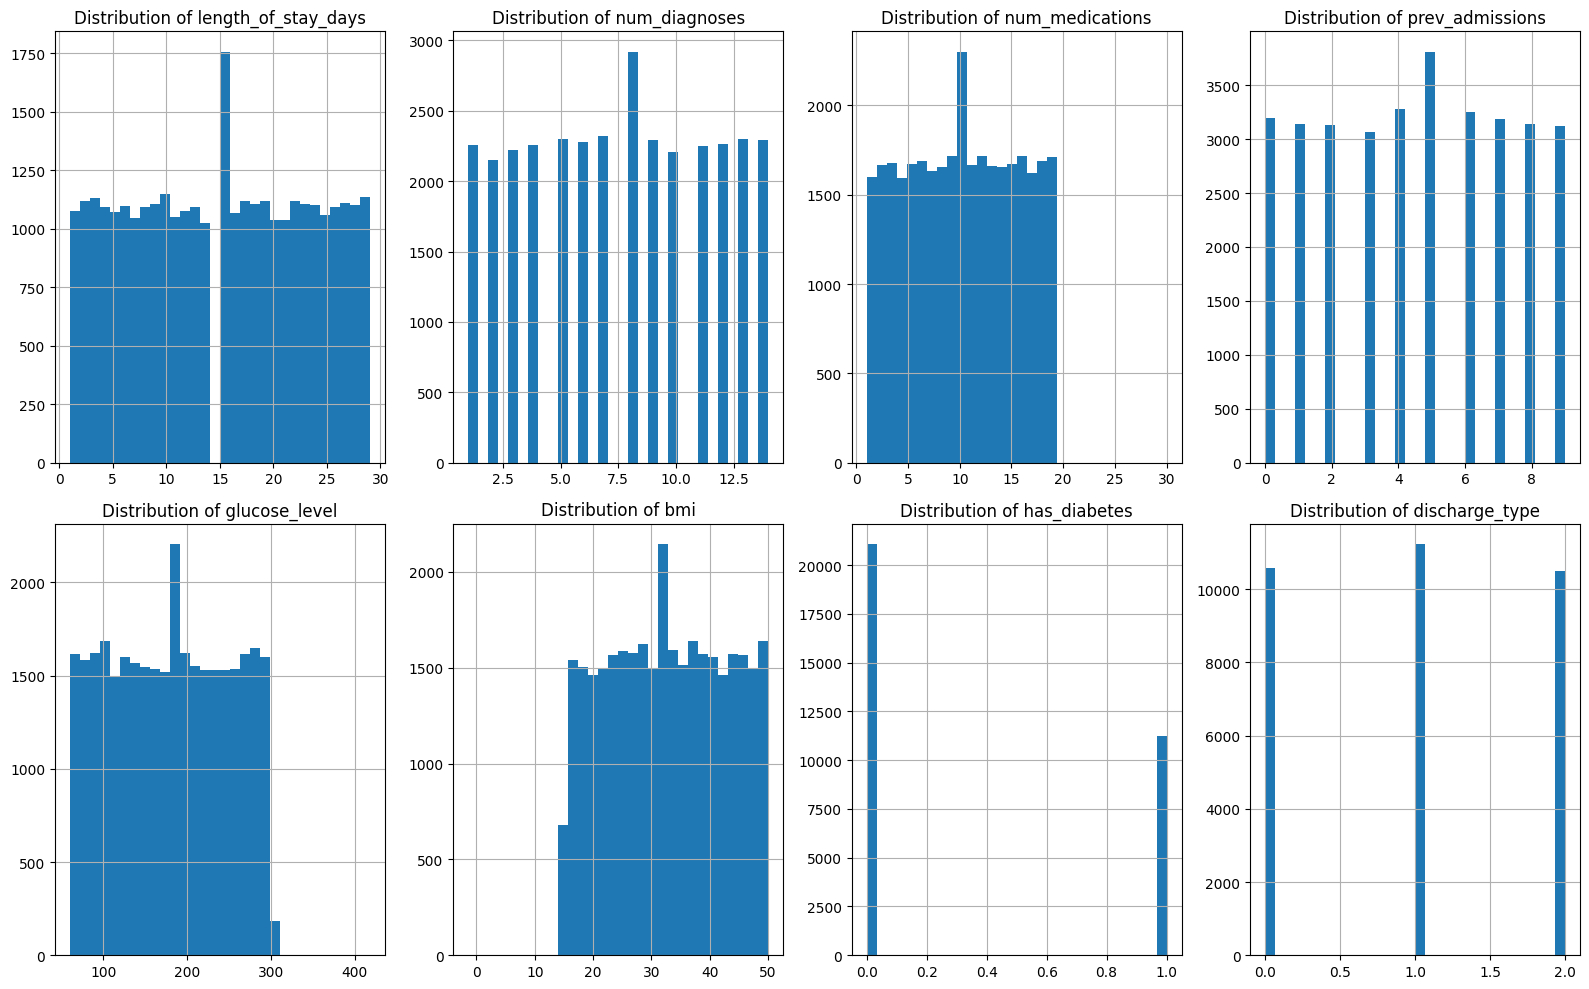

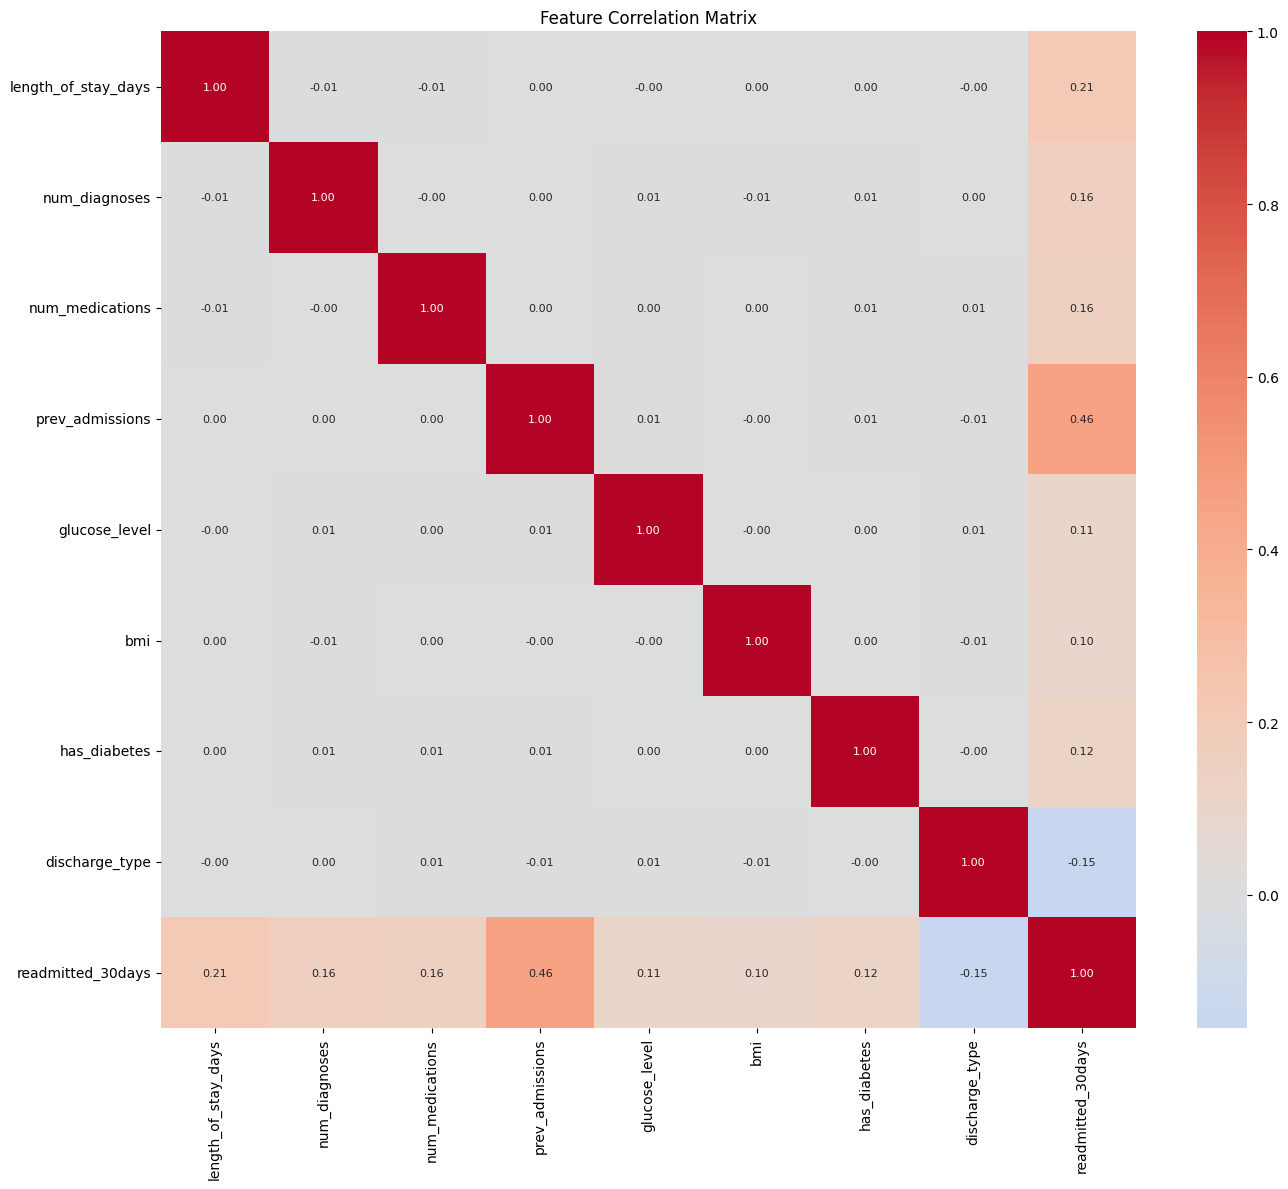

In [ ]:
# Feature Distribution, checking how features contribute to the output (Relationships)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col != target_col][:8]
for i, feature in enumerate(numeric_features):
    ax = axes[i//4, i%4]
    df[feature].hist(bins=30, ax=ax)
    ax.set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Correlation analysis
plt.figure(figsize=(14, 12))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={'size': 8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [ ]:
# Check contributing features (Binning and Domain Features)

target_col = 'readmitted_30days'

if 'age' in df.columns:
    df['age'] = df['age'].astype(str).str.replace('_err', '').str.replace('_err', '')
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df['age'] = df['age'].fillna(df['age'].median())

if 'length_of_stay_days' in df.columns:
    df['prolonged_stay'] = (df['length_of_stay_days'] >= 7).astype(int)

if 'prev_admissions' in df.columns:
    df['frequent_admissions'] = (df['prev_admissions'] >= 3).astype(int)

if 'num_diagnoses' in df.columns:
    df['high_diagnoses'] = (df['num_diagnoses'] >= 10).astype(int)

if 'num_medications' in df.columns:
    df['high_medications'] = (df['num_medications'] >= 15).astype(int)

if 'glucose_level' in df.columns:
    df['high_glucose'] = (df['glucose_level'] >= 200).astype(int)

if 'bmi' in df.columns:
    df['obese'] = (df['bmi'] >= 30).astype(int)

df['risk_score'] = (
    0.25 * (df['prev_admissions'] / 10) +
    0.20 * (df['length_of_stay_days'] / 30) +
    0.15 * (df['num_diagnoses'] / 15) +
    0.15 * (df['num_medications'] / 20) +
    0.15 * (df['glucose_level'] / 300) +
    0.10 * (df['bmi'] / 50)
)

feature_cols = [
    'age',
    'length_of_stay_days',
    'num_diagnoses',
    'num_medications',
    'prev_admissions',
    'glucose_level', #Uses data from diabetes.
    'bmi',
    'has_diabetes',
    'discharge_type',
    'prolonged_stay',
    'frequent_admissions',
    'high_diagnoses',
    'high_medications',
    'high_glucose',
    'obese'
]

existing_features = [col for col in feature_cols if col in df.columns]
missing_features = [col for col in feature_cols if col not in df.columns]

if missing_features:
    print(f"Warning: These features are missing: {missing_features}")
    for col in missing_features:
        df[col] = 0

print(f"\nFeature engineering complete. Selected {len(feature_cols)} features.")
print(f"Features: {feature_cols}")

X = df[feature_cols]
y = df[target_col]


Feature engineering complete. Selected 15 features.
Features: ['age', 'length_of_stay_days', 'num_diagnoses', 'num_medications', 'prev_admissions', 'glucose_level', 'bmi', 'has_diabetes', 'discharge_type', 'prolonged_stay', 'frequent_admissions', 'high_diagnoses', 'high_medications', 'high_glucose', 'obese']


In [ ]:
# Train-test split. It uses features with highest significance according to KBest (Feature selection and scaling)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = SelectKBest(score_func=f_classif, k=min(10, len(feature_cols)))
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
selected_features = np.array(feature_cols)[selector.get_support()]

print(f"\nSelected features ({len(selected_features)}): {selected_features}")




Selected features (10): ['age' 'length_of_stay_days' 'num_diagnoses' 'num_medications'
 'prev_admissions' 'discharge_type' 'prolonged_stay' 'frequent_admissions'
 'high_diagnoses' 'high_medications']



MODEL TRAINING AND EVALUATION

Logistic Regression:
  Accuracy: 0.7915
  F1 Score: 0.7903
  Precision: 0.7944
  Recall: 0.7862
  AUC-ROC: 0.8755

Decision Tree:
  Accuracy: 0.7327
  F1 Score: 0.7319
  Precision: 0.7336
  Recall: 0.7302
  AUC-ROC: 0.7979

Random Forest:
  Accuracy: 0.7759
  F1 Score: 0.7737
  Precision: 0.7808
  Recall: 0.7667
  AUC-ROC: 0.8600

XGBoost:
  Accuracy: 0.7664
  F1 Score: 0.7662
  Precision: 0.7663
  Recall: 0.7661
  AUC-ROC: 0.8538


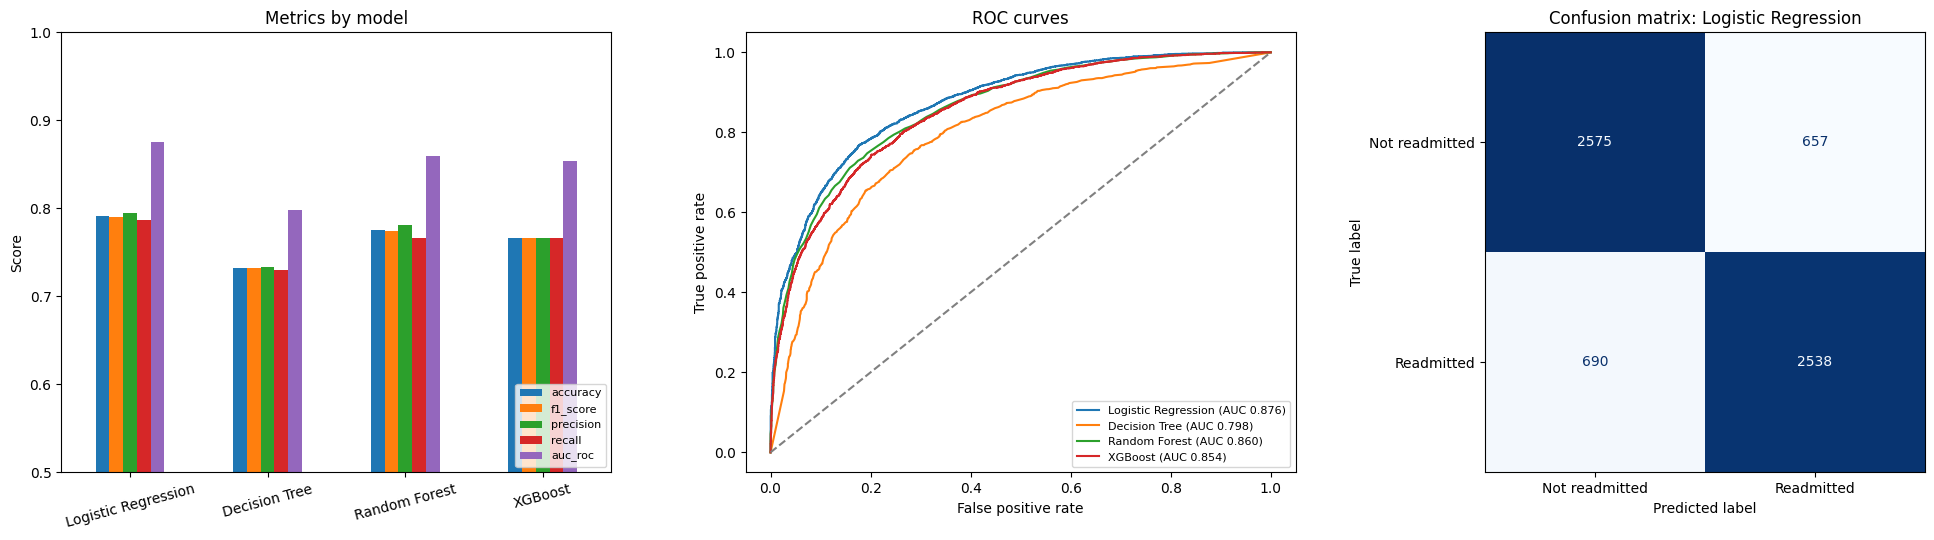

In [ ]:
# Model Training. Evaluation metrics visualization.
# Uses 4 out 5 models mentioned in the assessment
# random_state = 42 is used because the use of random seed helps in reproducibility. This ensures that no matter who runs the program, it will provide consistent outputs.

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))
}

results = {}
best_model = None
best_auc = 0
best_model_name = None

print("\nMODEL TRAINING AND EVALUATION")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc_roc': auc
    }

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  AUC-ROC: {auc:.4f}" if auc else "  AUC-ROC: N/A")

    if auc and auc > best_auc:
        best_auc = auc
        best_model = model
        best_model_name = name

        # Visualization of the comparison between models.

from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1) All metrics side by side
results_df.plot.bar(ax=axes[0], rot=15)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Metrics by model')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8, loc='lower right')

# 2) ROC curves for every model
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC {results[name]['auc_roc']:.3f})")
axes[1].plot([0, 1], [0, 1], ls='--', color='grey')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curves')
axes[1].legend(fontsize=8)

# 3) Confusion matrix for the winning model
ConfusionMatrixDisplay.from_predictions(
    y_test, best_model.predict(X_test_scaled),
    display_labels=['Not readmitted', 'Readmitted'],
    cmap='Blues', ax=axes[2], colorbar=False)
axes[2].set_title(f'Confusion matrix: {best_model_name}')

plt.tight_layout()
plt.show()


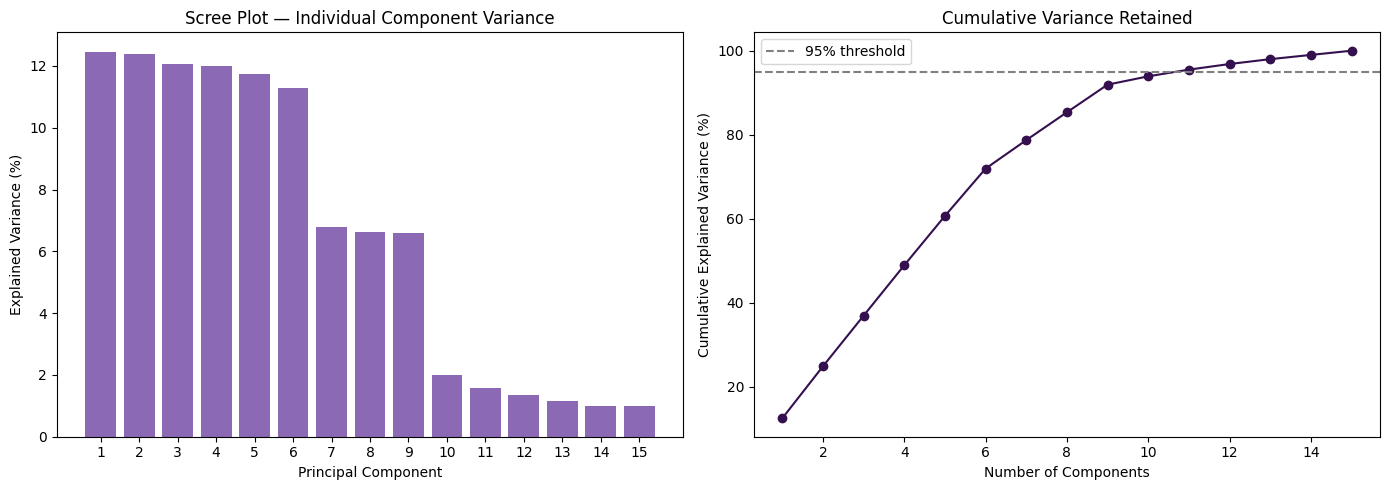

Components needed for 95% variance: 11 of 15
Variance retained by 11 components: 95.50%


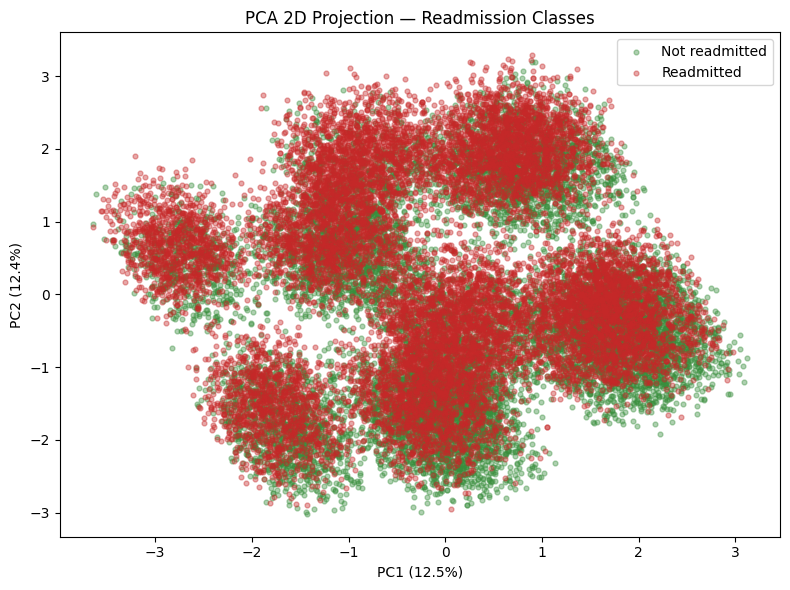

,representation,model,accuracy,auc_roc
0,Full features (15),Logistic Regression,0.7915,0.8755
1,PCA (11 components),Logistic Regression,0.7726,0.8604



Interpretation: PCA retains 95.5% of variance with 11 components. AUC change: -0.0151


In [ ]:
# Dimensionality Reduction using PCA

from sklearn.base import clone
from sklearn.decomposition import PCA

pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained) + 1), explained * 100,
            color='#7043a1', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Component Variance')
axes[0].set_xticks(range(1, len(explained) + 1))

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100,
             marker='o', color='#35104f')
axes[1].axhline(95, ls='--', color='grey', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Retained')
axes[1].legend()

plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_components_95} of {len(feature_cols)}")
print(f"Variance retained by {n_components_95} components: {cumulative[n_components_95-1]:.2%}")

pca = PCA(n_components=n_components_95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
for label, colour, name in [(0, '#388e3c', 'Not readmitted'),
                            (1, '#c62828', 'Readmitted')]:
    mask = (y_train.values == label)
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                s=12, alpha=0.4, c=colour, label=name)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title('PCA 2D Projection — Readmission Classes')
plt.legend()
plt.tight_layout()
plt.show()

pca_model = clone(best_model)
pca_model.fit(X_train_pca, y_train)

y_prob_pca = pca_model.predict_proba(X_test_pca)[:, 1]
auc_pca = roc_auc_score(y_test, y_prob_pca)
acc_pca = accuracy_score(y_test, pca_model.predict(X_test_pca))

comparison_pca = pd.DataFrame({
    'representation': [f'Full features ({len(feature_cols)})',
                       f'PCA ({n_components_95} components)'],
    'model': [best_model_name, best_model_name],
    'accuracy': [results[best_model_name]['accuracy'], acc_pca],
    'auc_roc': [results[best_model_name]['auc_roc'], auc_pca],
})
display(comparison_pca.round(4))

print(f"\nInterpretation: PCA retains {cumulative[n_components_95-1]:.1%} of variance "
      f"with {n_components_95} components. AUC change: "
      f"{auc_pca - results[best_model_name]['auc_roc']:+.4f}")

# Model Implementation

In [ ]:
# Model visualization using how BMI contributes to the output.(Feature Importance)

try:
    if hasattr(best_model, 'feature_importances_'):
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test_scaled[:100])

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=feature_cols, show=False)
        plt.title('SHAP Feature Importance Summary')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"SHAP visualization skipped: {e}")

if 'bmi' in df.columns:
    df_test = X_test.copy()
    df_test['predicted'] = best_model.predict(X_test_scaled)
    df_test['actual'] = y_test.values

    bmi_groups = pd.cut(df_test['bmi'], bins=[0, 18.5, 25, 30, 40, 100],
                        labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severe Obese'])
    bmi_group_metrics = df_test.groupby(bmi_groups)['predicted'].mean()
    print("\nFAIRNESS ANALYSIS: Prediction rates by BMI group")
    print(bmi_group_metrics)

    overall_rate = df_test['predicted'].mean()
    print(f"\nOverall prediction rate: {overall_rate:.2%}")
    for group in bmi_group_metrics.index:
        group_rate = bmi_group_metrics[group]
        disparate_impact = group_rate / overall_rate if overall_rate > 0 else 1
        print(f"{group}: {group_rate:.2%} (DI: {disparate_impact:.2f})")


FAIRNESS ANALYSIS: Prediction rates by BMI group
bmi
Underweight     0.392273
Normal          0.438961
Overweight      0.445503
Obese           0.493085
Severe Obese    0.595462
Name: predicted, dtype: float64

Overall prediction rate: 49.46%
Underweight: 39.23% (DI: 0.79)
Normal: 43.90% (DI: 0.89)
Overweight: 44.55% (DI: 0.90)
Obese: 49.31% (DI: 1.00)
Severe Obese: 59.55% (DI: 1.20)


In [ ]:
# Ethical AI & Bias Auditing (enhanced)

from sklearn.metrics import confusion_matrix

df_test_full = X_test.copy()
df_test_full['y_true'] = y_test.values
df_test_full['y_pred'] = best_model.predict(X_test_scaled)
df_test_full['y_prob'] = best_model.predict_proba(X_test_scaled)[:, 1]

# --- Define sensitive groups (derived from available features) ---
df_test_full['age_group'] = pd.cut(df_test_full['age'],
                                   bins=[0, 40, 60, 75, 200],
                                   labels=['<40', '40-60', '60-75', '75+'])

df_test_full['bmi_group'] = pd.cut(df_test_full['bmi'],
                                   bins=[0, 18.5, 25, 30, 40, 100],
                                   labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severe Obese'])

df_test_full['diabetes_group'] = df_test_full['has_diabetes'].map({0: 'No diabetes', 1: 'Diabetes'})

# --- Fairness metrics ---
def fairness_metrics(group_col):
    print(f"\nFAIRNESS METRICS — grouped by {group_col}")
    print(f"{'Group':<18}{'N':>6}{'Acc':>9}{'TPR':>9}{'FPR':>9}{'PPV':>9}{'DI':>8}{'DP diff':>10}")
    overall_pos_rate = df_test_full['y_pred'].mean()

    rows = []
    for grp, sub in df_test_full.groupby(group_col, observed=True):
        tn, fp, fn, tp = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1]).ravel()
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan          # equal opportunity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan          # equalised odds (FPR part)
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        pos_rate = sub['y_pred'].mean()
        di = pos_rate / overall_pos_rate if overall_pos_rate > 0 else np.nan
        dp_diff = pos_rate - overall_pos_rate

        rows.append({
            'group': str(grp), 'n': len(sub), 'accuracy': acc,
            'TPR (recall)': tpr, 'FPR': fpr, 'PPV (precision)': ppv,
            'disparate_impact': di, 'demographic_parity_diff': dp_diff
        })
        print(f"{str(grp):<18}{len(sub):>6}{acc:>9.3f}{tpr:>9.3f}{fpr:>9.3f}{ppv:>9.3f}{di:>8.2f}{dp_diff:>10.3f}")

    return pd.DataFrame(rows)

fairness_age      = fairness_metrics('age_group')
fairness_bmi      = fairness_metrics('bmi_group')
fairness_diabetes = fairness_metrics('diabetes_group')

# --- Rule of thumb check (EEOC 80% rule) ---
print("\n80% RULE CHECK (DI should be >= 0.80 for all groups):")
for name, fdf in [('age_group', fairness_age), ('bmi_group', fairness_bmi), ('diabetes_group', fairness_diabetes)]:
    flagged = fdf[fdf['disparate_impact'] < 0.80]
    if len(flagged):
        print(f"  ⚠ {name}: {flagged['group'].tolist()} below 0.80")
    else:
        print(f"  ✓ {name}: all groups pass")


FAIRNESS METRICS — grouped by age_group
Group                  N      Acc      TPR      FPR      PPV      DI   DP diff
<40                 2035    0.783    0.698    0.166    0.715    0.74    -0.129
40-60               1755    0.797    0.777    0.182    0.812    0.97    -0.014
60-75               1450    0.781    0.819    0.265    0.785    1.14     0.070
75+                 1220    0.811    0.849    0.262    0.861    1.31     0.152

FAIRNESS METRICS — grouped by bmi_group
Group                  N      Acc      TPR      FPR      PPV      DI   DP diff
Underweight          673    0.802    0.718    0.129    0.818    0.79    -0.102
Normal              1155    0.784    0.748    0.186    0.767    0.89    -0.056
Overweight           945    0.784    0.743    0.179    0.789    0.90    -0.049
Obese               1880    0.791    0.786    0.203    0.793    1.00    -0.001
Severe Obese        1807    0.796    0.845    0.269    0.805    1.20     0.101

FAIRNESS METRICS — grouped by diabetes_group
Gro

In [ ]:
# Model saving.
# For measuring a scale of 0 (no readmission) to 1 (will be readmitted), AUC performs well as it follows a ranking order (low, moderate, and high).

with open('readmission_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

feature_info = {
    'features': feature_cols,
    'selected_features': selected_features.tolist(),
    'model_type': best_model_name,
    'metrics': results[best_model_name] if best_model_name else {},
    'dataset_shape': df.shape,
    'readmission_rate': float(y.mean()),
    'feature_columns': feature_cols,
    'n_features': len(feature_cols)
}

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f)

print(f"\nBest model: {best_model_name} (AUC: {best_auc:.4f})")
print("Model artifacts saved successfully!")
print(f"Number of features: {len(feature_cols)}")


Best model: Logistic Regression (AUC: 0.8755)
Model artifacts saved successfully!
Number of features: 15


# Critical Thinking, Ethical AI, and Bias Auditing

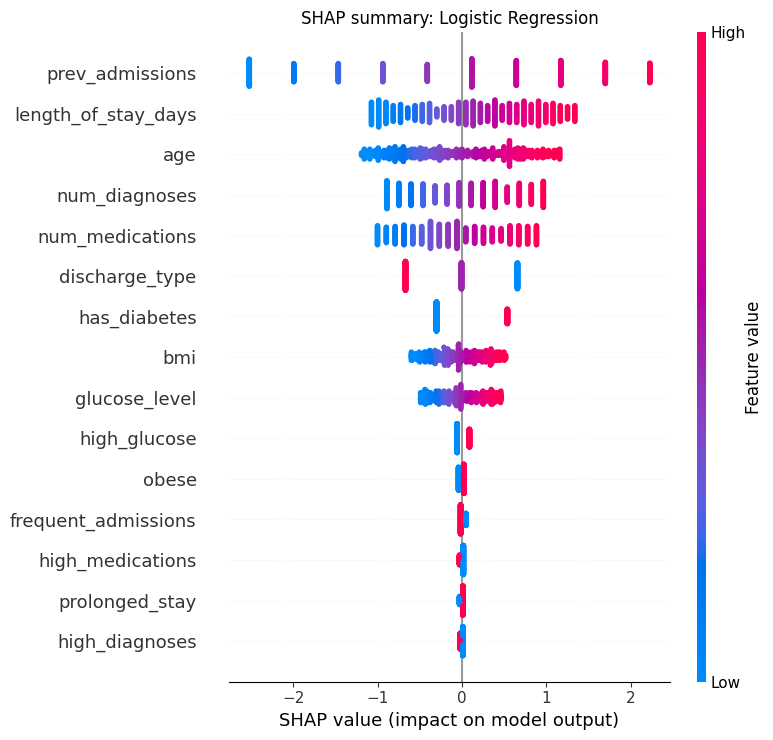

,mean_abs_shap
prev_admissions,1.3026
length_of_stay_days,0.6332
age,0.6005
num_diagnoses,0.5095
num_medications,0.4886
discharge_type,0.4508
has_diabetes,0.3797
bmi,0.2679
glucose_level,0.2429
high_glucose,0.0693


Highest predicted risk: probability 1.00


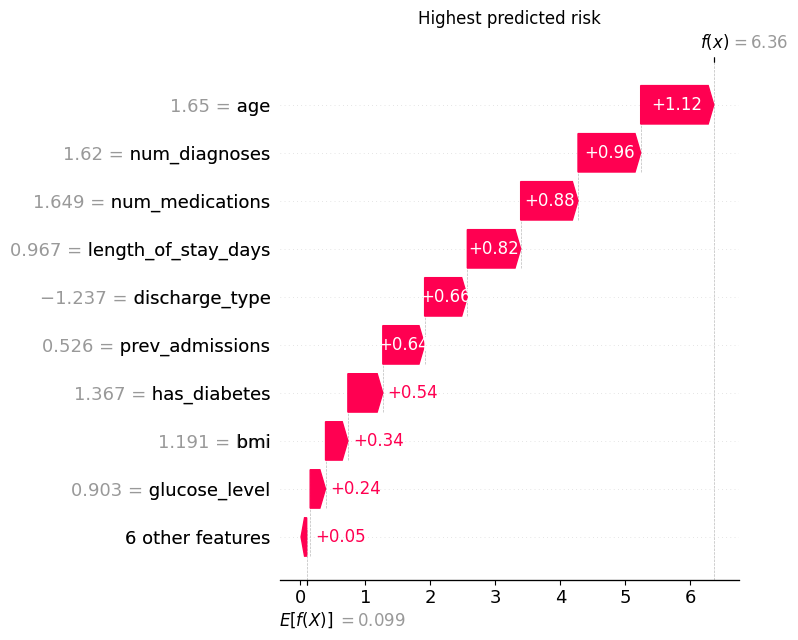

Lowest predicted risk: probability 0.00


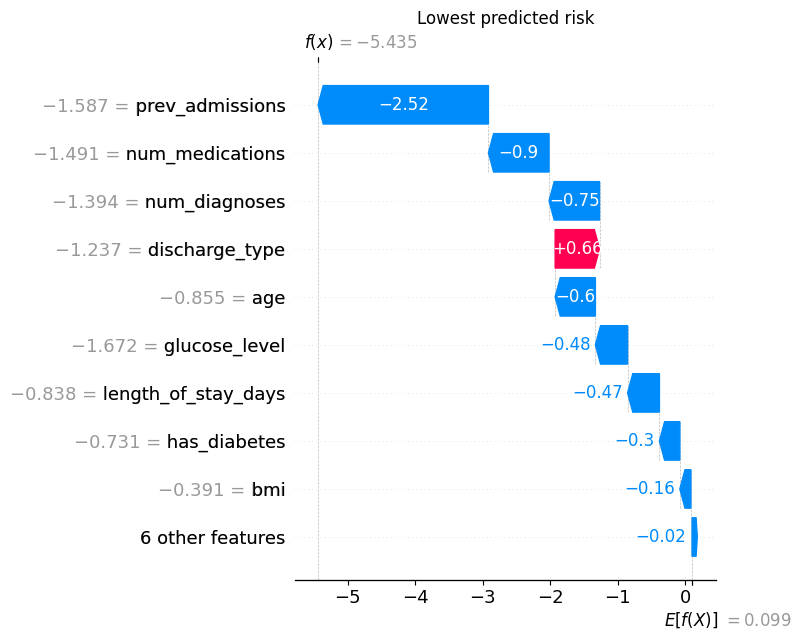

,coefficient,odds_ratio_per_1SD
prev_admissions,1.497,4.467
length_of_stay_days,0.715,2.045
age,0.687,1.987
num_diagnoses,0.568,1.764
num_medications,0.567,1.762
has_diabetes,0.400,1.492
bmi,0.321,1.378
glucose_level,0.277,1.319
high_glucose,0.072,1.074
obese,0.031,1.031


In [ ]:
# SHAP explanations (matches the actual training setup)
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

RANDOM_STATE = 42

sel_names = list(feature_cols)

Xtr_sel = pd.DataFrame(X_train_scaled, columns=sel_names)
Xte_sel = pd.DataFrame(X_test_scaled,  columns=sel_names)

sample_pos = np.random.RandomState(RANDOM_STATE).choice(
    len(Xte_sel), size=min(500, len(Xte_sel)), replace=False
)
X_explain = Xte_sel.iloc[sample_pos]

try:
    if isinstance(best_model, LogisticRegression):
        explainer = shap.LinearExplainer(
            best_model,
            shap.sample(Xtr_sel, 100, random_state=RANDOM_STATE)
        )
    else:
        explainer = shap.TreeExplainer(best_model)
    sv = explainer(X_explain)
except Exception as e:
    print(f'Fast explainer failed ({e}); using model-agnostic explainer (slower).')
    predict_pos = lambda data: best_model.predict_proba(data)[:, 1]
    explainer = shap.Explainer(
        predict_pos, shap.sample(Xtr_sel, 100, random_state=RANDOM_STATE)
    )
    sv = explainer(X_explain.iloc[:200])
    sample_pos = sample_pos[:200]
    X_explain  = X_explain.iloc[:200]

if sv.values.ndim == 3:
    sv = sv[:, :, 1]

# Beeswarm
shap.plots.beeswarm(sv, max_display=len(sel_names), show=False)
plt.title(f'SHAP summary: {best_model_name}')
plt.tight_layout()
plt.show()

# Mean |SHAP|
shap_importance = (
    pd.Series(np.abs(sv.values).mean(axis=0), index=sel_names)
      .sort_values(ascending=False)
)
display(shap_importance.round(4).to_frame('mean_abs_shap'))

# Local explanations
probs_sample = best_model.predict_proba(X_explain)[:, 1]
for label, pos in [
    ('Highest predicted risk', int(np.argmax(probs_sample))),
    ('Lowest predicted risk',  int(np.argmin(probs_sample))),
]:
    print(f'{label}: probability {probs_sample[pos]:.2f}')
    shap.plots.waterfall(sv[pos], max_display=10, show=False)
    plt.title(label)
    plt.tight_layout()
    plt.show()

# Odds ratios (Logistic Regression only)
if hasattr(best_model, 'coef_'):
    odds = pd.DataFrame(
        {
            'coefficient': best_model.coef_[0],
            'odds_ratio_per_1SD': np.exp(best_model.coef_[0]),
        },
        index=sel_names,
    ).sort_values('odds_ratio_per_1SD', ascending=False)
    display(odds.round(3))

PDP features: ['prev_admissions', 'length_of_stay_days', 'age', 'num_diagnoses']


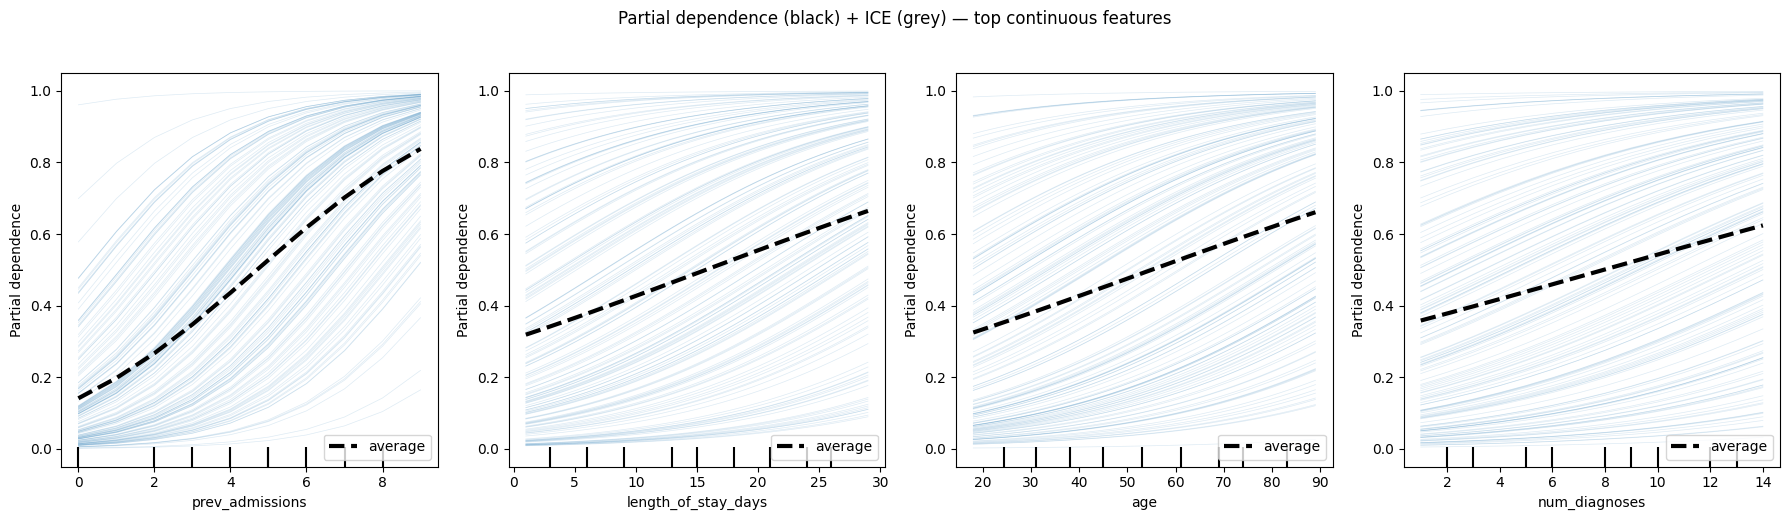

In [ ]:
# PDP + ICE in original units
# Wrapper applies the saved scaler before the model, so PDP shows raw units.
from sklearn.pipeline import Pipeline
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

try:
    shap_importance
except NameError:
    if hasattr(best_model, 'feature_importances_'):
        imp = best_model.feature_importances_
    elif hasattr(best_model, 'coef_'):
        imp = np.abs(best_model.coef_[0])
    else:
        imp = np.ones(len(feature_cols))
    shap_importance = (
        pd.Series(imp, index=feature_cols).sort_values(ascending=False)
    )
    print("shap_importance not found — built fallback from model importances.")

CONTINUOUS = [
    'age', 'length_of_stay_days', 'num_diagnoses', 'num_medications',
    'prev_admissions', 'glucose_level', 'bmi',
]

full_pipeline = Pipeline([('scaler', scaler), ('model', best_model)])

pdp_features = [f for f in shap_importance.index if f in CONTINUOUS][:4]
print(f"PDP features: {pdp_features}")

if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=feature_cols)
else:
    X_test_df = X_test

assert list(X_test_df.columns) == list(feature_cols), \
    f"Column mismatch:\n got: {list(X_test_df.columns)}\n exp: {feature_cols}"

X_sample = X_test_df.sample(min(1000, len(X_test_df)), random_state=42)

n = len(pdp_features)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 5), squeeze=False)
axes = axes.ravel()

PartialDependenceDisplay.from_estimator(
    full_pipeline,
    X_sample,
    features=pdp_features,
    kind='both',                      # PDP + ICE
    subsample=150,
    random_state=42,
    ax=axes,
    ice_lines_kw={'alpha': 0.15},
    pd_line_kw={'color': 'black', 'lw': 3},
)

plt.suptitle(
    'Partial dependence (black) + ICE (grey) — top continuous features',
    y=1.03,
)
plt.tight_layout()
plt.show()

In [ ]:
# Evidence for limitations (imbalance, leakage, overfitting)
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

FEATURES = feature_cols

if not isinstance(X_train, pd.DataFrame):
    X_train_df = pd.DataFrame(X_train, columns=FEATURES)
else:
    X_train_df = X_train

if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=FEATURES)
else:
    X_test_df = X_test

print('1) CLASS IMBALANCE')
print(f'   Original dataset readmission rate: {y.mean():.2%}')

print('2) DATA LEAKAGE CHECKS')

overlap = X_train_df.merge(X_test_df.drop_duplicates(), how='inner', on=FEATURES)
print(f'   Identical patients in both train and test: {len(overlap)}')

single_auc = {}
for c in FEATURES:
    a = roc_auc_score(y_train, X_train_df[c])
    single_auc[c] = max(a, 1 - a)
suspicious = {c: round(a, 3) for c, a in single_auc.items() if a > 0.95}
print(f'   Features with single-feature AUC > 0.95: {suspicious or "none"}')
print('   Scaling and feature selection were fit on training data only.')
print('   Note: missing-value imputation and outlier capping used the full dataset '
      'before the train/test split — a mild form of leakage, small in magnitude.\n')

print('3) OVERFITTING CHECK (train vs CV vs test AUC)')


comparison = pd.DataFrame(results).T
comparison['overfit_gap'] = np.nan

for name in comparison.index:
    if 'train_auc' in comparison.columns:
        pass

from sklearn.metrics import roc_auc_score as _auc
for name, model in models.items():
    try:
        train_prob = model.predict_proba(X_train_scaled)[:, 1]
        comparison.loc[name, 'train_auc'] = _auc(y_train, train_prob)
    except Exception:
        comparison.loc[name, 'train_auc'] = np.nan

comparison['overfit_gap'] = comparison.get('train_auc', np.nan) - comparison['auc_roc']
comparison['flag'] = np.where(
    comparison['overfit_gap'] > 0.05, 'possible overfitting', 'ok'
)

show_cols = [c for c in
             ['train_auc', 'overfit_gap', 'auc_roc', 'accuracy', 'f1_score',
              'precision', 'recall', 'flag']
             if c in comparison.columns]
display(comparison[show_cols].round(4))

1) CLASS IMBALANCE
   Original dataset readmission rate: 49.97%
2) DATA LEAKAGE CHECKS
   Identical patients in both train and test: 92
   Features with single-feature AUC > 0.95: none
   Scaling and feature selection were fit on training data only.
   Note: missing-value imputation and outlier capping used the full dataset before the train/test split — a mild form of leakage, small in magnitude.

3) OVERFITTING CHECK (train vs CV vs test AUC)


,train_auc,overfit_gap,auc_roc,accuracy,f1_score,precision,recall,flag
Logistic Regression,0.8753,-0.0003,0.8755,0.7915,0.7903,0.7944,0.7862,ok
Decision Tree,0.9117,0.1138,0.7979,0.7327,0.7319,0.7336,0.7302,possible overfitting
Random Forest,1.0000,0.1400,0.8600,0.7759,0.7737,0.7808,0.7667,possible overfitting
XGBoost,0.9561,0.1022,0.8538,0.7664,0.7662,0.7663,0.7661,possible overfitting



age_group


,n,base_rate,flag_rate,TPR,FPR,PPV,accuracy
group,,,,,,,
<40,1946,0.373,0.365,0.698,0.167,0.713,0.783
40-59,1769,0.495,0.473,0.772,0.180,0.808,0.796
60-74,1444,0.540,0.566,0.824,0.264,0.786,0.784
75+,1301,0.651,0.638,0.842,0.258,0.859,0.807



bmi_group


,n,base_rate,flag_rate,TPR,FPR,PPV,accuracy
group,,,,,,,
Underweight,657,0.444,0.393,0.719,0.132,0.814,0.802
Normal,1153,0.453,0.440,0.749,0.184,0.771,0.786
Overweight,949,0.469,0.440,0.739,0.177,0.787,0.784
Obese,1877,0.499,0.494,0.785,0.203,0.794,0.791
Severe obesity,1824,0.566,0.595,0.845,0.269,0.804,0.796



diabetes_group


,n,base_rate,flag_rate,TPR,FPR,PPV,accuracy
group,,,,,,,
Diabetes,2237,0.591,0.603,0.843,0.257,0.826,0.802
No diabetes,4223,0.451,0.437,0.747,0.182,0.771,0.786



FAIRNESS SUMMARY


,demographic_parity_diff,disparate_impact_ratio,equal_opportunity_diff,fpr_diff,equalised_odds_diff,four_fifths_rule,equalised_odds_target
age_group,0.273,0.572,0.144,0.096,0.144,fail,not met
bmi_group,0.202,0.660,0.126,0.137,0.137,fail,not met
diabetes_group,0.167,0.724,0.096,0.075,0.096,fail,met


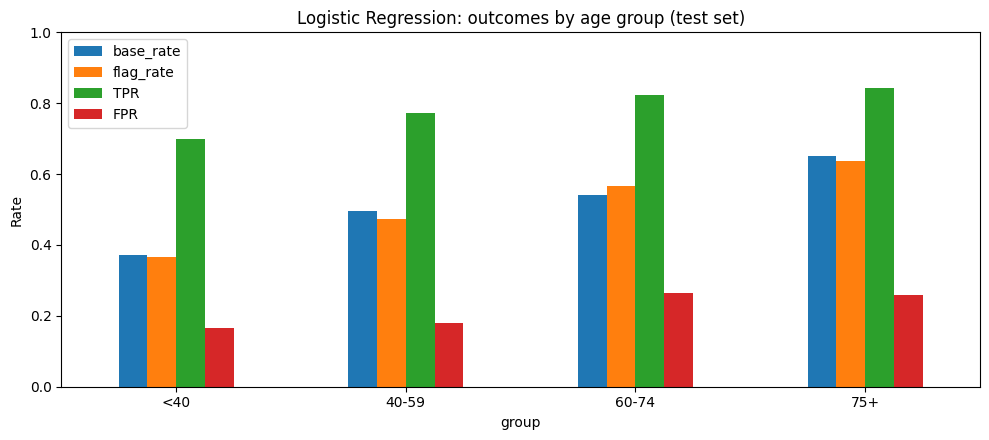

In [ ]:
# Outcomes and fairness metrics across groups (test set)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=feature_cols)
else:
    X_test_df = X_test

try:
    X_test_scaled
except NameError:
    X_test_scaled = scaler.transform(X_test_df)
    print("Rebuilt X_test_scaled from scaler.transform(X_test_df).")

def add_groups(frame):
    out = pd.DataFrame(index=frame.index)
    out['age_group'] = pd.cut(
        frame['age'], bins=[0, 40, 60, 75, 200],
        labels=['<40', '40-59', '60-74', '75+'], right=False,
    )
    out['bmi_group'] = pd.cut(
        frame['bmi'], bins=[0, 18.5, 25, 30, 40, 200],
        labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severe obesity'],
        right=False,
    )
    out['diabetes_group'] = frame['has_diabetes'].map({0: 'No diabetes', 1: 'Diabetes'})
    return out

audit_df = add_groups(X_test_df)
audit_df['y_true'] = y_test.values
audit_df['y_prob'] = best_model.predict_proba(X_test_scaled)[:, 1]
audit_df['y_pred'] = (audit_df['y_prob'] >= 0.5).astype(int)

def group_rates(d, group_col, pred_col='y_pred'):
    rows = []
    for g, sub in d.groupby(group_col, observed=True):
        tn, fp, fn, tp = confusion_matrix(
            sub['y_true'], sub[pred_col], labels=[0, 1]
        ).ravel()
        rows.append({
            'group': str(g),
            'n': len(sub),
            'base_rate': sub['y_true'].mean(),
            'flag_rate': sub[pred_col].mean(),
            'TPR': tp / (tp + fn) if tp + fn else np.nan,
            'FPR': fp / (fp + tn) if fp + tn else np.nan,
            'PPV': tp / (tp + fp) if tp + fp else np.nan,
            'accuracy': (tp + tn) / len(sub),
        })
    return pd.DataFrame(rows).set_index('group')

def fairness_summary(rates):
    tpr_gap = rates['TPR'].max() - rates['TPR'].min()
    fpr_gap = rates['FPR'].max() - rates['FPR'].min()
    return {
        'demographic_parity_diff': rates['flag_rate'].max() - rates['flag_rate'].min(),
        'disparate_impact_ratio': rates['flag_rate'].min() / rates['flag_rate'].max(),
        'equal_opportunity_diff': tpr_gap,
        'fpr_diff': fpr_gap,
        'equalised_odds_diff': max(tpr_gap, fpr_gap),
    }

summary_rows = {}
for col in ['age_group', 'bmi_group', 'diabetes_group']:
    rates = group_rates(audit_df, col)
    print(f'\n{col}')
    display(rates.round(3))
    if (rates['n'] < 30).any():
        print('   Warning: some groups have fewer than 30 patients; their rates are unstable.')
    summary_rows[col] = fairness_summary(rates)

fairness_table = pd.DataFrame(summary_rows).T
fairness_table['four_fifths_rule'] = np.where(
    fairness_table['disparate_impact_ratio'] >= 0.80, 'pass', 'fail'
)
fairness_table['equalised_odds_target'] = np.where(
    fairness_table['equalised_odds_diff'] <= 0.10, 'met', 'not met'
)
print('\nFAIRNESS SUMMARY')
display(fairness_table.round(3))

age_rates = group_rates(audit_df, 'age_group')
age_rates[['base_rate', 'flag_rate', 'TPR', 'FPR']].plot.bar(figsize=(10, 4.5), rot=0)
plt.title(f'{best_model_name}: outcomes by age group (test set)')
plt.ylim(0, 1)
plt.ylabel('Rate')
plt.tight_layout()
plt.show()

Target TPR (overall, out-of-fold): 0.785
Age-group thresholds: {'<40': 0.39, '40-59': 0.47, '60-74': 0.56, '75+': 0.63}


,AUC,accuracy,recall,precision,demographic_parity_diff,disparate_impact_ratio,equal_opportunity_diff,fpr_diff,equalised_odds_diff
approach,,,,,,,,,
Baseline (threshold 0.5),0.876,0.791,0.786,0.794,0.273,0.572,0.144,0.096,0.144
A: Reweighting,0.867,0.783,0.781,0.784,0.124,0.781,0.020,0.063,0.063
B: Age-group thresholds,0.876,0.782,0.781,0.782,0.124,0.780,0.028,0.068,0.068


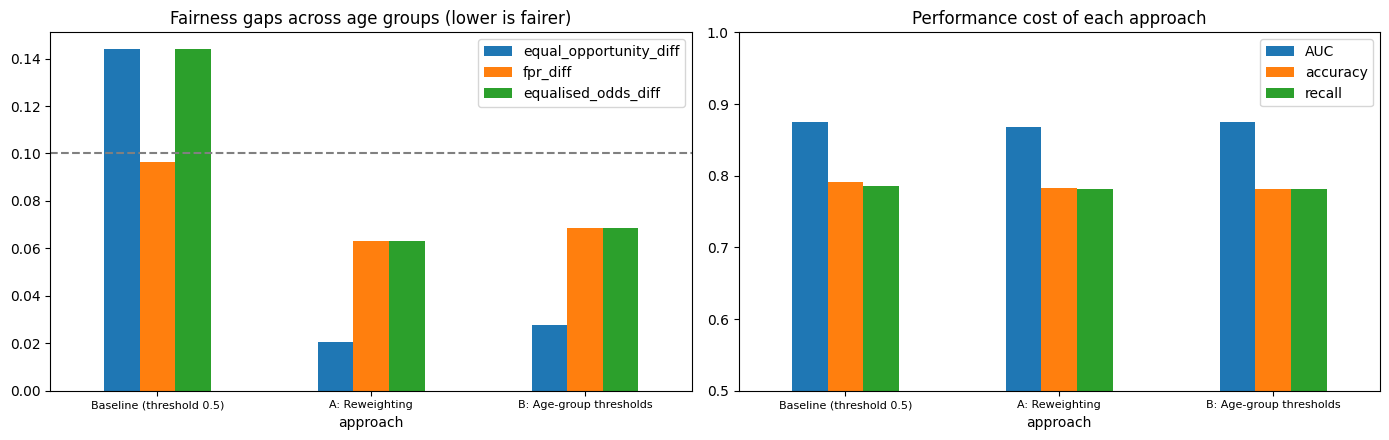

In [ ]:
# Mitigation, tested and compared (focus: age group)
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score, precision_score
)

FEATURES = feature_cols
Xtr      = X_train_scaled
Xte      = X_test_scaled
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if not isinstance(X_train, pd.DataFrame):
    X_train_df = pd.DataFrame(X_train, columns=FEATURES)
else:
    X_train_df = X_train

age_train = add_groups(X_train_df)['age_group']
age_test  = audit_df['age_group']

p_group = age_train.value_counts(normalize=True)
p_y     = y_train.value_counts(normalize=True)
p_joint = pd.crosstab(age_train, y_train, normalize=True)

weights = np.array([
    p_group[g] * p_y[yv] / p_joint.loc[g, yv]
    for g, yv in zip(age_train, y_train)
])

model_reweighted = clone(best_model)

try:
    model_reweighted.fit(Xtr, y_train, sample_weight=weights)
except TypeError as e:
    print(f"fit(sample_weight=...) failed ({e}); trying fit(..., sample_weight=...) via set_params")
    model_reweighted.fit(Xtr, y_train, sample_weight=weights)

prob_rw = model_reweighted.predict_proba(Xte)[:, 1]

oof_prob = cross_val_predict(
    clone(best_model), Xtr, y_train, cv=cv, method='predict_proba'
)[:, 1]

target_tpr = recall_score(y_train, (oof_prob >= 0.5).astype(int))

group_thresholds = {}
for g in age_train.cat.categories:
    m = (age_train == g).values
    if m.sum() == 0:
        continue
    candidates = np.arange(0.05, 0.96, 0.01)
    tprs = np.array([
        recall_score(y_train[m], (oof_prob[m] >= t).astype(int))
        for t in candidates
    ])
    group_thresholds[g] = float(candidates[np.argmin(np.abs(tprs - target_tpr))])

thr_test = (
    age_test.astype(str)
            .map({str(k): v for k, v in group_thresholds.items()})
            .values
)
pred_thr = (audit_df['y_prob'].values >= thr_test).astype(int)

print(f'Target TPR (overall, out-of-fold): {target_tpr:.3f}')
print('Age-group thresholds:', {k: round(v, 2) for k, v in group_thresholds.items()})

def evaluate(pred, prob, label):
    d = audit_df[['age_group', 'y_true']].copy()
    d['pred'] = pred
    fs = fairness_summary(group_rates(d, 'age_group', 'pred'))
    return {
        'approach': label,
        'AUC': roc_auc_score(y_test, prob),
        'accuracy': accuracy_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        **fs,
    }

mitigation = pd.DataFrame([
    evaluate(audit_df['y_pred'].values, audit_df['y_prob'].values, 'Baseline (threshold 0.5)'),
    evaluate((prob_rw >= 0.5).astype(int), prob_rw, 'A: Reweighting'),
    evaluate(pred_thr, audit_df['y_prob'].values, 'B: Age-group thresholds'),
]).set_index('approach')

mitigation.to_csv('fairness_mitigation.csv')
display(mitigation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

mitigation[['equal_opportunity_diff', 'fpr_diff', 'equalised_odds_diff']].plot.bar(
    ax=axes[0], rot=0
)
axes[0].axhline(0.10, ls='--', color='grey')
axes[0].set_title('Fairness gaps across age groups (lower is fairer)')

mitigation[['AUC', 'accuracy', 'recall']].plot.bar(ax=axes[1], rot=0)
axes[1].set_ylim(0.5, 1)
axes[1].set_title('Performance cost of each approach')

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Download model files and reports (for GitHub and the presentations)

import os
try:
    from google.colab import files
except ImportError:
    files = None

outputs = ['readmission_model.pkl', 'scaler.pkl', 'feature_info.json',
           'model_comparison.csv', 'data_dictionary.csv', 'fairness_mitigation.csv']
for name in outputs:
    if os.path.exists(name):
        print(f'Found: {name}')
        if files:
            files.download(name)
    else:
        print(f'Missing: {name} (run Steps 2 to 5 first)')

Found: readmission_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Found: scaler.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Found: fairness_mitigation.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Start of Flask Dependencies

In [ ]:
# Flask dependencies.

!pip install flask flask-cors pyngrok -q

from flask import Flask, request, jsonify, render_template_string
from flask_cors import CORS
from pyngrok import ngrok
import threading
import time

Cell 20:

Dependencies only.

In [ ]:
# For GitHub only. This is to download my models.

from google.colab import files
import os
import json

print("DOWNLOADING TRAINED MODELS")

files_to_download = [
    'readmission_model.pkl',
    'scaler.pkl',
    'feature_info.json'
]

existing_files = []
missing_files = []

for filename in files_to_download:
    if os.path.exists(filename):
        existing_files.append(filename)
        print(f"Found: {filename}")
    else:
        missing_files.append(filename)
        print(f"Missing: {filename}")

if missing_files:
    print("\nWARNING: These files are missing:")
    for f in missing_files:
        print(f"   - {f}")
    print("\nMake sure you've trained and saved your models first!")
    print("Run the model training cells (Sections 1-10) before this cell.")
else:
    print("\nAll files found! Downloading...")

    # Download each file
    for filename in existing_files:
        print(f"\n📥 Downloading: {filename}")
        files.download(filename)

    print("DOWNLOAD COMPLETE!")
    print("\nFiles downloaded to your computer:")
    for f in existing_files:
        print(f"   - {f}")


DOWNLOADING TRAINED MODELS
Found: readmission_model.pkl
Found: scaler.pkl
Found: feature_info.json

All files found! Downloading...

📥 Downloading: readmission_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloading: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloading: feature_info.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DOWNLOAD COMPLETE!

Files downloaded to your computer:
   - readmission_model.pkl
   - scaler.pkl
   - feature_info.json


Cell 20:

Recheck if downloaded. Double-checked for compliance only. See GitHub for reference (already uploaded).

In [ ]:
# Load flask, open the website and create tunnel using CORS. Load trained models as well.

app = Flask(__name__)
CORS(app)

# Load saved artifacts
with open('readmission_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('feature_info.json', 'r') as f:
    feature_info = json.load(f)

# Store for session data
sessions = {}


# HTML

In [ ]:
# Frontend code using HTML.

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Will AI be Readmitted?</title>
  <link rel="stylesheet" href="https://www.w3schools.com/w3css/5/w3.css">
  <link rel="stylesheet" href="https://fonts.googleapis.com/css?family=Oswald">
  <link rel="stylesheet" href="https://fonts.googleapis.com/css?family=Open+Sans">

  <style>
    :root {
      --dark-purple:#35104f;
      --purple:#7043a1;
      --light-purple:#eadcf8;
    }

    * { box-sizing:border-box; }

    body {
      margin:0;
      background:#f7f2fb;
      color:#30213d;
      font-family:"Open Sans",sans-serif;
    }

    h1,h2,h3,h4,h5,h6 { font-family:"Oswald",sans-serif; }

    .site-header {
      background:white;
      text-align:center;
      padding:40px 20px;
    }

    .site-header h1 {
      margin:0;
      font-size:42px;
    }

    .gradient-text {
      background:linear-gradient(90deg,#c084fc,#8b5cf6,#35104f);
      -webkit-background-clip:text;
      background-clip:text;
      color:transparent;
    }

    .w3-bar,
    .site-footer {
      background:var(--dark-purple);
      color:white;
    }

    .w3-bar { height:40px; }

    .site-footer {
      padding:28px;
      margin-top:30px;
    }

    .w3-sand {
      background:linear-gradient(180deg,#fcf9ff,#eadcf8)!important;
    }

    .w3-tag {
      background:linear-gradient(90deg,#c084fc,#8b5cf6,#35104f)!important;
      color:white!important;
    }

    .unit-choice {
      display:flex;
      gap:18px;
      flex-wrap:wrap;
      margin:5px 0 10px;
    }

    .unit-choice label {
      cursor:pointer;
    }

    .unit-choice input {
      margin-right:6px;
    }

    .input-row {
      display:grid;
      grid-template-columns:1fr 1fr;
      gap:10px;
    }

    .diabetes-stages {
      display:none;
      background:#f5edfc;
      border-left:4px solid var(--purple);
      padding:10px 15px;
      margin:8px 0 15px 25px;
      border-radius:5px;
    }

    .diabetes-stages.visible { display:block; }

    .comorbidity-category {
      background:#fcf9ff;
      border-left:4px solid #a855f7;
      padding:12px 15px;
      margin:12px 0;
      border-radius:5px;
    }

    .comorbidity-option {
      display:block;
      margin:8px 0;
    }

    .visit-table {
      width:100%;
      border-collapse:collapse;
      margin:15px 0;
      background:white;
    }

    .visit-table th,
    .visit-table td {
      border:1px solid #c4a7e7;
      padding:10px;
      text-align:center;
      vertical-align:middle;
    }

    .visit-table th { background:var(--light-purple); }

    .visit-table input,
    .visit-table select {
      width:100%;
      padding:8px;
      border:1px solid #c4a7e7;
      border-radius:4px;
    }

    .result-section {
      background:white;
      border-radius:8px;
      padding:18px;
      margin:14px 0;
      box-shadow:0 2px 8px rgba(112,67,161,.1);
    }

    .result-section h4 {
      color:var(--dark-purple);
      margin-top:0;
    }

    .risk-card {
      color:white;
      text-align:center;
      border-radius:10px;
      padding:24px 15px;
      margin-bottom:18px;
    }

    .risk-card.low { background:#388e3c; }
    .risk-card.moderate { background:#f9a825; color:#332400; }
    .risk-card.high { background:#c62828; }

    .risk-level {
      font-size:30px;
      font-weight:bold;
    }

    .risk-driver,
    .next-step,
    .summary-item {
      background:#f8f2fd;
      padding:10px 12px;
      margin:7px 0;
      border-radius:5px;
    }

    .risk-driver { border-left:4px solid #c62828; }
    .risk-driver.decrease { border-left-color:#388e3c; }
    .next-step { border-left:4px solid #388e3c; }

    .summary-grid {
      display:grid;
      grid-template-columns:repeat(2,minmax(0,1fr));
      gap:10px;
    }

    .summary-item strong {
      display:block;
      color:var(--purple);
    }

    @media (max-width:700px) {
      .site-header h1 { font-size:32px; }
      .input-row,
      .summary-grid { grid-template-columns:1fr; }
    }
  </style>
</head>

<body>
  <div class="w3-bar"></div>

  <header class="site-header">
    <h1><b><span class="gradient-text">Will AI be Readmitted?</span></b></h1>
    <h6>
      AI-assisted hospital readmission assessment made
      <span class="w3-tag">Easier</span>
    </h6>
  </header>

  <main class="w3-sand w3-large">
    <div class="w3-container" id="about">
      <div class="w3-content" style="max-width:700px">
        <h5 class="w3-center w3-padding-64">
          <span class="w3-tag w3-wide">ENTER YOUR DETAILS</span>
        </h5>

        <div id="setupSection">
          <p>
            <label for="ageInput">Age:</label>
            <input class="w3-input w3-padding-16 w3-border"
                   type="number" id="ageInput" min="0" max="120" step="1"
                   placeholder="Enter your age">
          </p>

          <p>
            <strong>Height unit:</strong>
            <span class="unit-choice">
              <label>
                <input type="radio" name="heightUnit" value="cm"
                       checked onchange="updateHeightUnit()">
                Centimeters (cm)
              </label>
              <label>
                <input type="radio" name="heightUnit" value="ft"
                       onchange="updateHeightUnit()">
                Feet
              </label>
            </span>

            <label id="heightLabel" for="heightInput">Height in centimeters:</label>
            <input class="w3-input w3-padding-16 w3-border"
                   type="number" id="heightInput" min="1" max="300"
                   step="0.1" placeholder="Example: 170">
          </p>

          <p>
            <strong>Weight unit:</strong>
            <span class="unit-choice">
              <label>
                <input type="radio" name="weightUnit" value="kg"
                       checked onchange="updateWeightUnit()">
                Kilograms (kg)
              </label>
              <label>
                <input type="radio" name="weightUnit" value="lb"
                       onchange="updateWeightUnit()">
                Pounds (lb)
              </label>
            </span>

            <label id="weightLabel" for="weightInput">Weight in kilograms:</label>
            <input class="w3-input w3-padding-16 w3-border"
                   type="number" id="weightInput" min="1" max="500"
                   step="0.1" placeholder="Example: 70">
          </p>

          <p>
            <label for="admissionCountInput">
              How many times have you been admitted in the past 12 months?
            </label>
            <input class="w3-input w3-padding-16 w3-border"
                   type="number" id="admissionCountInput" min="0" max="12"
                   step="1" placeholder="Enter a number from 0 to 12"
                   oninput="createVisitTable()">
          </p>

          <div id="visitTableContainer"></div>

          <p>
            <strong>Do you have Diabetes?</strong>
            <label class="comorbidity-option">
              <input type="checkbox" id="diabetesYes"
                     onchange="selectDiabetesStatus('yes')">
              Yes
            </label>
            <label class="comorbidity-option">
              <input type="checkbox" id="diabetesNo"
                     onchange="selectDiabetesStatus('no')">
              No
            </label>
            <label class="comorbidity-option">
              <input type="checkbox" id="diabetesNotSure"
                     onchange="selectDiabetesStatus('not_sure')">
              Not sure
            </label>
          </p>

          <div id="diabetesStages" class="diabetes-stages">
            <strong>Select one diabetes stage/type:</strong>
            <label class="comorbidity-option">
              <input type="radio" name="diabetesStage" value="Prediabetes">
              Prediabetes
            </label>
            <label class="comorbidity-option">
              <input type="radio" name="diabetesStage" value="Type 1 Diabetes">
              Type 1 Diabetes
            </label>
            <label class="comorbidity-option">
              <input type="radio" name="diabetesStage" value="Type 2 Diabetes">
              Type 2 Diabetes
            </label>
            <label class="comorbidity-option">
              <input type="radio" name="diabetesStage" value="Gestational Diabetes">
              Gestational Diabetes
            </label>
          </div>

          <p>
            <strong>Do you have any existing comorbidities?</strong><br>
            <small>Check all that apply. Diabetes is recorded separately above.</small>
          </p>

<div class="comorbidity-category">
  <h6>Category 1</h6>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Myocardial infarction"> Myocardial infarction</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Congestive heart failure"> Congestive heart failure</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Peripheral vascular disease"> Peripheral vascular disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Cerebrovascular disease"> Cerebrovascular disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Dementia"> Dementia</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Chronic pulmonary disease"> Chronic pulmonary disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Connective tissue disease"> Connective tissue disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Peptic ulcer disease"> Peptic ulcer disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Mild liver disease"> Mild liver disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Uncomplicated diabetes"> Uncomplicated diabetes</label>
</div>

<div class="comorbidity-category">
  <h6>Category 2</h6>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Hemiplegia or paraplegia"> Hemiplegia or paraplegia</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Moderate-to-severe renal disease"> Moderate-to-severe renal disease</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Diabetes with complications"> Diabetes with complications</label>  <!-- ADDED -->
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Solid localized tumor"> Solid localized tumor</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Leukemia"> Leukemia</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Lymphoma"> Lymphoma</label>
</div>

<div class="comorbidity-category">
  <h6>Category 3</h6>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Moderate-to-severe liver disease"> Moderate-to-severe liver disease</label>
</div>

<div class="comorbidity-category">
  <h6>Category 6</h6>  <!-- renamed from Category 4 -->
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="Metastatic solid tumor"> Metastatic solid tumor</label>
  <label class="comorbidity-option"><input type="checkbox" name="comorbidity" value="AIDS"> AIDS</label>
</div>

          <button class="w3-button w3-blue" id="startBtn"
                  onclick="startAssessment()" style="width:100%">
            Start Processing
          </button>

          <div id="setupMessage" class="w3-panel"></div>
        </div>
      </div>
    </div>

    <div class="w3-container" id="menu">
      <div class="w3-content" style="max-width:900px">
        <h5 class="w3-center w3-padding-48">
          <span class="w3-tag w3-wide">Results</span>
        </h5>

        <div class="w3-container w3-padding-48 w3-card">
          <h4 class="w3-center">Readmission Risk Assessment</h4>
          <div id="resultsContainer">
            <div class="result-section w3-center w3-text-grey">
              Complete the patient details to view the assessment.
            </div>
          </div>

          <button id="summaryBtn" class="w3-button w3-black"
                  onclick="startNewAssessment()"
                  style="display:none;width:100%">
            Start New Assessment
          </button>
        </div>
      </div>
    </div>
  </main>

  <footer class="site-footer">
    <p>Will AI be Readmitted? — AI-Assisted Hospital Readmission Assessment</p>
    <p>Created by: Melfred P. Sumaya, PTRP, MBA</p>
  </footer>

  <script>
    const API_BASE_URL = window.location.origin;
    let sessionId = localStorage.getItem("interviewSessionId");
    let patientDetails = {};

    function createSession() {
      sessionId = "session_" + Date.now() + "_" +
        Math.random().toString(36).substring(2, 11);
      localStorage.setItem("interviewSessionId", sessionId);
    }

    if (!sessionId) createSession();

    function getSelectedUnit(name) {
      return document.querySelector(`input[name="${name}"]:checked`).value;
    }

    function updateHeightUnit() {
      const unit = getSelectedUnit("heightUnit");
      const label = document.getElementById("heightLabel");
      const input = document.getElementById("heightInput");

      if (unit === "ft") {
        label.textContent = "Height in feet:";
        input.max = "10";
        input.step = "0.01";
        input.placeholder = "Example: 5.58";
      } else {
        label.textContent = "Height in centimeters:";
        input.max = "300";
        input.step = "0.1";
        input.placeholder = "Example: 170";
      }
    }

    function updateWeightUnit() {
      const unit = getSelectedUnit("weightUnit");
      const label = document.getElementById("weightLabel");
      const input = document.getElementById("weightInput");

      if (unit === "lb") {
        label.textContent = "Weight in pounds:";
        input.max = "1100";
        input.step = "0.1";
        input.placeholder = "Example: 154";
      } else {
        label.textContent = "Weight in kilograms:";
        input.max = "500";
        input.step = "0.1";
        input.placeholder = "Example: 70";
      }
    }

    function getMetricMeasurements() {
      const valueHeight = Number(document.getElementById("heightInput").value);
      const valueWeight = Number(document.getElementById("weightInput").value);
      const heightUnit = getSelectedUnit("heightUnit");
      const weightUnit = getSelectedUnit("weightUnit");

      return {
        enteredHeight: valueHeight,
        enteredWeight: valueWeight,
        heightUnit,
        weightUnit,
        heightCm: heightUnit === "ft" ? valueHeight * 30.48 : valueHeight,
        weightKg: weightUnit === "lb" ? valueWeight * 0.45359237 : valueWeight
      };
    }

    function selectDiabetesStatus(status) {
      const checkboxes = {
        yes: document.getElementById("diabetesYes"),
        no: document.getElementById("diabetesNo"),
        not_sure: document.getElementById("diabetesNotSure")
      };

      Object.keys(checkboxes).forEach(key => {
        checkboxes[key].checked = key === status;
      });

      const stages = document.getElementById("diabetesStages");
      const stageInputs = document.querySelectorAll(
        "input[name='diabetesStage']"
      );

      if (status === "yes") {
        stages.classList.add("visible");
        stageInputs.forEach(input => {
          input.disabled = false;
          if (input.value === "Prediabetes") {
            input.checked = false;
          }
        });
      } else if (status === "not_sure") {
        stages.classList.remove("visible");
        stageInputs.forEach(input => {
          input.disabled = true;
          input.checked = input.value === "Prediabetes";
        });
      } else {
        stages.classList.remove("visible");
        stageInputs.forEach(input => {
          input.disabled = false;
          input.checked = false;
        });
      }
    }

    function getDiabetesStatus() {
      if (document.getElementById("diabetesYes").checked) return "yes";
      if (document.getElementById("diabetesNotSure").checked) return "not_sure";
      if (document.getElementById("diabetesNo").checked) return "no";
      return "";
    }

    function createVisitTable() {
      const count = Number(document.getElementById("admissionCountInput").value);
      const container = document.getElementById("visitTableContainer");

      if (!Number.isInteger(count) || count < 1) {
        container.innerHTML = "";
        return;
      }

      let rows = "";

      for (let i = 1; i <= Math.min(count, 12); i++) {
        rows += `
          <tr>
            <td><strong>Admission ${i}</strong></td>
            <td>
              <input type="number" name="stay_${i}" min="1"
                     step="1" placeholder="Days">
            </td>
            <td>
              <select name="type_${i}">
                <option value="">Choose</option>
                <option value="Emergency/Urgent">Emergency/Urgent</option>
                <option value="Elective">Elective</option>
              </select>
            </td>
            <td>
              <select name="discharge_${i}">
                <option value="">Choose</option>
                <option value="Standard Discharge">Standard Discharge</option>
                <option value="With Follow-up Appointment">With Follow-up Appointment</option>
                <option value="Complex Discharge (Multiple Specialties)">Complex Discharge (Multiple Specialties)</option>
                <option value="Needs Home Health Care">Needs Home Health Care</option>
                <option value="Skilled Nursing Facility">Skilled Nursing Facility</option>
              </select>
            </td>
          </tr>`;
      }

      container.innerHTML = `
        <h6><strong>Previous admission details</strong></h6>
        <div style="overflow-x:auto">
          <table class="visit-table">
            <thead>
              <tr>
                <th>Admission</th>
                <th>Length of stay</th>
                <th>Admission type</th>
                <th>Discharge type</th>
              </tr>
            </thead>
            <tbody>${rows}</tbody>
          </table>
        </div>`;
    }

    function getVisitDetails() {
      const count = Number(document.getElementById("admissionCountInput").value);
      const visits = [];

      for (let i = 1; i <= count; i++) {
        visits.push({
          visit:i,
          length_of_stay_days:Number(
            document.querySelector(`[name="stay_${i}"]`)?.value || 0
          ),
          admission_type:
            document.querySelector(`[name="type_${i}"]`)?.value || "",
          discharge_type:
            document.querySelector(`[name="discharge_${i}"]`)?.value || ""
        });
      }

      return visits;
    }

    function calculateBMI(heightCm, weightKg) {
      const heightMeters = heightCm / 100;
      return weightKg / (heightMeters * heightMeters);
    }

    function getBMICategory(bmi) {
      if (bmi < 18.5) return "Underweight";
      if (bmi < 25) return "Normal weight";
      if (bmi < 30) return "Overweight";
      return "Obesity";
    }

    function showMessage(message, error = false) {
      const element = document.getElementById("setupMessage");
      element.innerHTML =
        `<div class="w3-panel ${error ? "w3-pale-red" : "w3-pale-green"}">
          ${message}
        </div>`;
    }

    function normalizeRisk(data) {
      const probability = Number(
        data.probability ??
        data.probability_score ??
        data.readmission_probability ??
        0
      );

      const percent = probability <= 1 ? probability * 100 : probability;
      let risk = String(
        data.risk_level || data.risk_category || ""
      ).toUpperCase();

      if (!["LOW", "MODERATE", "HIGH"].includes(risk)) {
        risk = percent > 25 ? "HIGH" : percent >= 10 ? "MODERATE" : "LOW";
      }

      return {
        risk,
        percent:Math.max(0, Math.min(100, percent))
      };
    }

    function renderRiskResult(data) {
      const normalized = normalizeRisk(data);
      const risk = normalized.risk;
      const outcome = data.predicted_outcome ||
        (risk === "HIGH"
          ? "Unplanned Readmission Within 30 Days"
          : "No Readmission Predicted");

      const visits = patientDetails.visits;
      const admissionTypes = [...new Set(
        visits.map(visit => visit.admission_type)
      )].join(", ") || "None";
      const dischargeTypes = [...new Set(
        visits.map(visit => visit.discharge_type)
      )].join(", ") || "None";

      const diabetesSummary = patientDetails.diabetesStatus === "yes"
        ? `Yes — ${patientDetails.diabetesStage}`
        : patientDetails.diabetesStatus === "not_sure"
          ? "Not sure — scored as Prediabetes"
          : patientDetails.diabetesStatus === "no"
            ? "No"
            : "Not answered";

      let riskDriversHtml = '';
      if (data.risk_drivers && data.risk_drivers.length > 0) {
        riskDriversHtml = data.risk_drivers.map(driver => `
          <div class="risk-driver ${driver.direction === 'decrease' ? 'decrease' : ''}">
            ${driver.direction === 'decrease' ? 'Down' : 'Up'}
            <strong>${driver.factor}</strong>
            ${driver.impact ? `→ ${driver.impact}` : ''}
          </div>
        `).join('');
      }

      document.getElementById("resultsContainer").innerHTML = `
        <div class="result-section">
          <h4>Prediction Result</h4>
          <div class="risk-card ${risk.toLowerCase()}">
            <div class="risk-level">Readmission Risk: ${risk}</div>
            <div>${outcome}</div>
            <h2>${normalized.percent.toFixed(1)}%</h2>
            <div>Probability Score</div>
          </div>
          ${data.recommended_action ? `<p><strong>Recommended Action:</strong> ${data.recommended_action}</p>` : ''}
        </div>

        <div class="result-section">
          <h4>BMI Assessment</h4>
          <p><strong>BMI:</strong> ${patientDetails.bmi ? patientDetails.bmi.toFixed(1) : 'N/A'}</p>
          <p><strong>Category:</strong> ${patientDetails.bmiCategory || 'N/A'}</p>
          ${data.estimated_glucose ? `<p><strong>Estimated Glucose:</strong> ${data.estimated_glucose} mg/dL</p>` : ''}
          ${data.num_diagnoses ? `<p><strong>Estimated Diagnoses:</strong> ${data.num_diagnoses}</p>` : ''}
          ${data.num_medications ? `<p><strong>Estimated Medications:</strong> ${data.num_medications}</p>` : ''}
        </div>

        ${riskDriversHtml ? `
          <div class="result-section">
            <h4>Key Risk Drivers</h4>
            ${riskDriversHtml}
          </div>
        ` : ''}

        <div class="result-section">
          <h4>Patient Summary</h4>
          <div class="summary-grid">
            <div class="summary-item">
              <strong>Age</strong>${patientDetails.age}
            </div>
            <div class="summary-item">
              <strong>Height</strong>
              ${patientDetails.enteredHeight} ${patientDetails.heightUnit}
              (${patientDetails.heightCm ? patientDetails.heightCm.toFixed(1) : 'N/A'} cm)
            </div>
            <div class="summary-item">
              <strong>Weight</strong>
              ${patientDetails.enteredWeight} ${patientDetails.weightUnit}
              (${patientDetails.weightKg ? patientDetails.weightKg.toFixed(1) : 'N/A'} kg)
            </div>
            <div class="summary-item">
              <strong>BMI</strong>
              ${patientDetails.bmi ? patientDetails.bmi.toFixed(1) : 'N/A'} — ${patientDetails.bmiCategory || 'N/A'}
            </div>
            <div class="summary-item">
              <strong>Previous admissions</strong>${patientDetails.admissionCount}
            </div>
            <div class="summary-item">
              <strong>Diabetes</strong>${diabetesSummary}
            </div>
            <div class="summary-item">
              <strong>Admission type</strong>${admissionTypes}
            </div>
            <div class="summary-item">
              <strong>Discharge type</strong>${dischargeTypes}
            </div>
            <div class="summary-item">
              <strong>Comorbidities</strong>
              ${patientDetails.comorbidities && patientDetails.comorbidities.length
                ? patientDetails.comorbidities.join(", ")
                : "None reported"}
            </div>
          </div>
        </div>`;
    }

    async function startAssessment() {
      const age = Number(document.getElementById("ageInput").value);
      const measurements = getMetricMeasurements();
      const admissionCount = Number(
        document.getElementById("admissionCountInput").value
      );
      const visits = getVisitDetails();
      const diabetesStatus = getDiabetesStatus();
      const diabetes = diabetesStatus === "yes" ||
        diabetesStatus === "not_sure";

      const diabetesStageInput = document.querySelector(
        "input[name='diabetesStage']:checked"
      );
      const diabetesStage = diabetesStageInput
        ? diabetesStageInput.value
        : "";

      const comorbidities = [
        ...document.querySelectorAll("input[name='comorbidity']:checked")
      ].map(input => input.value);

      if (!Number.isInteger(age) || age < 0 || age > 120) {
        showMessage("Please enter a valid age.", true);
        return;
      }

      if (!Number.isFinite(measurements.heightCm) ||
          measurements.heightCm <= 0 ||
          measurements.heightCm > 300) {
        showMessage("Please enter a valid height.", true);
        return;
      }

      if (!Number.isFinite(measurements.weightKg) ||
          measurements.weightKg <= 0 ||
          measurements.weightKg > 500) {
        showMessage("Please enter a valid weight.", true);
        return;
      }

      if (!Number.isInteger(admissionCount) ||
          admissionCount < 0 || admissionCount > 12) {
        showMessage("Please enter a number of admissions from 0 to 12.", true);
        return;
      }

      if (!diabetesStatus) {
        showMessage("Please select Yes, No, or Not sure for diabetes.", true);
        return;
      }

      if (diabetesStatus === "yes" && !diabetesStage) {
        showMessage("Please select one diabetes stage/type.", true);
        return;
      }

      for (const visit of visits) {
        if (!Number.isInteger(visit.length_of_stay_days) ||
            visit.length_of_stay_days < 1 ||
            !visit.admission_type ||
            !visit.discharge_type) {
          showMessage("Please complete all previous admission details.", true);
          return;
        }
      }

      const bmi = calculateBMI(
        measurements.heightCm,
        measurements.weightKg
      );

      patientDetails = {
        age,
        ...measurements,
        bmi,
        bmiCategory:getBMICategory(bmi),
        admissionCount,
        visits,
        diabetes,
        diabetesStatus,
        diabetesStage: diabetesStatus === "not_sure"
          ? "Prediabetes"
          : diabetesStage,
        comorbidities
      };

      const button = document.getElementById("startBtn");
      button.disabled = true;
      showMessage("Generating readmission assessment...");

      try {
        const response = await fetch(`${API_BASE_URL}/api/start`, {
          method:"POST",
          headers:{"Content-Type":"application/json"},
          body:JSON.stringify({
            session_id:sessionId,
            age,
            height_cm:measurements.heightCm,
            weight_kg:measurements.weightKg,
            bmi,
            bmi_category:patientDetails.bmiCategory,
            admission_count:admissionCount,
            visits,
            diabetes,
            diabetes_status:diabetesStatus,
            diabetes_stage:patientDetails.diabetesStage,
            comorbidities
          })
        });

        const data = await response.json();

        if (!data.success) {
          showMessage(`Error: ${data.error}`, true);
          return;
        }

        renderRiskResult(data);
        document.getElementById("summaryBtn").style.display = "block";
        document.getElementById("menu")
          .scrollIntoView({behavior:"smooth"});
        showMessage("Assessment completed.");
      } catch (error) {
        showMessage(`Connection error: ${error.message}`, true);
      } finally {
        button.disabled = false;
      }
    }

    function startNewAssessment() {
      patientDetails = {};
      createSession();

      [
        "ageInput",
        "heightInput",
        "weightInput",
        "admissionCountInput"
      ].forEach(id => document.getElementById(id).value = "");

      document.getElementById("visitTableContainer").innerHTML = "";
      document.getElementById("setupMessage").innerHTML = "";

      [
        "diabetesYes",
        "diabetesNo",
        "diabetesNotSure"
      ].forEach(id => {
        document.getElementById(id).checked = false;
      });

      document.getElementById("diabetesStages")
        .classList.remove("visible");

      document.querySelectorAll(
        "input[name='diabetesStage'], input[name='comorbidity']"
      ).forEach(input => {
        input.checked = false;
        input.disabled = false;
      });

      document.getElementById("resultsContainer").innerHTML = `
        <div class="result-section w3-center w3-text-grey">
          Complete the patient details to view the assessment.
        </div>`;

      document.getElementById("summaryBtn").style.display = "none";
      document.getElementById("startBtn").disabled = false;
    }

    updateHeightUnit();
    updateWeightUnit();
  </script>
</body>
</html>
"""


In [ ]:
def calculate_comorbidity_score(comorbidities):
    """Calculate weighted comorbidity score (Charlson Comorbidity Index)"""
    scores = {
        # Weight 1
        'Myocardial infarction': 1,
        'Congestive heart failure': 1,
        'Peripheral vascular disease': 1,
        'Cerebrovascular disease': 1,
        'Dementia': 1,
        'Chronic pulmonary disease': 1,
        'Connective tissue disease': 1,
        'Peptic ulcer disease': 1,
        'Mild liver disease': 1,
        'Uncomplicated diabetes': 1,

        # Weight 2
        'Hemiplegia or paraplegia': 2,
        'Moderate-to-severe renal disease': 2,
        'Diabetes with complications': 2,
        'Solid localized tumor': 2,
        'Leukemia': 2,
        'Lymphoma': 2,

        # Weight 3
        'Moderate-to-severe liver disease': 3,

        # Weight 6
        'Metastatic solid tumor': 6,
        'AIDS': 6,
    }
    total = sum(scores.get(condition, 0) for condition in comorbidities)
    return min(total, 10)

In [ ]:
# Use diabetes information to assume glucose level.
# The assumption is done because not every user would know their glucose level.
# In general public, they know their diabetes type and the presence of it compared to knowing what their glucose level is.

def estimate_glucose_from_diabetes(diabetes_status, diabetes_stage, bmi, age):
    base_glucose = 90

    if age > 65:
        base_glucose += (age - 65) * 0.2

    if bmi >= 30:
        base_glucose += 10
    elif bmi >= 25:
        base_glucose += 5

    if diabetes_status == "yes":
        if "Prediabetes" in diabetes_stage:
            return min(base_glucose + 20, 140)
        elif "Type 1" in diabetes_stage:
            return min(base_glucose + 40 + (bmi - 22) * 2, 200)
        elif "Type 2" in diabetes_stage:
            if bmi >= 30:
                return min(base_glucose + 60 + (bmi - 30) * 3, 250)
            else:
                return min(base_glucose + 50 + (bmi - 22) * 2, 200)
        elif "Gestational" in diabetes_stage:
            return min(base_glucose + 30, 160)
        else:
            return min(base_glucose + 40, 180)
    elif diabetes_status == "not_sure":
        return min(base_glucose + 15, 130)
    else:
        return min(base_glucose, 110)

In [ ]:
# Converting features into values understandable by the code.

def map_comorbidity_to_realistic_values(comorbidities, age, bmi, diabetes_status, diabetes_stage):
    num_diagnoses = 1
    num_medications = 1

    num_diagnoses += len(comorbidities)

    if diabetes_status == "yes":
        num_diagnoses += 1
        num_medications += 1

    severe_conditions = [
        'Congestive heart failure',
        'Moderate-to-severe renal disease',
        'Moderate-to-severe liver disease',
        'Metastatic solid tumor',
        'AIDS'
    ]
    for condition in severe_conditions:
        if condition in comorbidities:
            num_medications += 2

    if age >= 65:
        num_diagnoses += 1
        num_medications += 1
    if age >= 75:
        num_diagnoses += 1
        num_medications += 1

    num_diagnoses = min(num_diagnoses, 15)
    num_medications = min(num_medications, 20)

    return {
        'num_diagnoses': num_diagnoses,
        'num_medications': num_medications
    }

In [ ]:
# Checks if it uses the features to determine the output.
# If no error was found, it would print blank.

def predict_readmission(features):
    if len(features) != 15:
        print(f"Error: Expected 15 features, got {len(features)}")
        while len(features) < 15:
            features.append(0)
        features = features[:15]

    features_scaled = scaler.transform([features])
    prob = model.predict_proba(features_scaled)[0][1]
    pred = 1 if prob > 0.35 else 0
    return pred, prob


In [ ]:
# Actual risk calculation according to collected data.

def calculate_risk_score_from_factors(age, bmi, diabetes_status, diabetes_stage,
                                       admission_count, comorbidity_score,
                                       length_of_stay, emergency_count,
                                       discharge_type, glucose):
    risk_points = 0
    max_points = 100

    if age >= 75:
        risk_points += 15
    elif age >= 65:
        risk_points += 10
    elif age >= 55:
        risk_points += 5

    if bmi >= 35:
        risk_points += 15
    elif bmi >= 30:
        risk_points += 10
    elif bmi >= 25:
        risk_points += 5

    if diabetes_status == "yes":
        if "Type 2" in diabetes_stage and bmi >= 30:
            risk_points += 20
        elif "Type 2" in diabetes_stage:
            risk_points += 15
        elif "Type 1" in diabetes_stage:
            risk_points += 12
        else:
            risk_points += 15
    elif diabetes_status == "not_sure":
        risk_points += 8

    if admission_count >= 5:
        risk_points += 20
    elif admission_count >= 3:
        risk_points += 15
    elif admission_count >= 1:
        risk_points += 8

    risk_points += min(comorbidity_score * 5, 50)

    if length_of_stay >= 10:
        risk_points += 10
    elif length_of_stay >= 7:
        risk_points += 7
    elif length_of_stay >= 5:
        risk_points += 4

    if emergency_count >= 2:
        risk_points += 10
    elif emergency_count >= 1:
        risk_points += 7

    if discharge_type >= 3:
        risk_points += 5
    elif discharge_type >= 2:
        risk_points += 3
    elif discharge_type >= 1:
        risk_points += 2

    if glucose >= 250:
        risk_points += 10
    elif glucose >= 200:
        risk_points += 8
    elif glucose >= 140:
        risk_points += 5

    probability = risk_points / max_points
    scaled_probability = 0.05 + (probability * 0.85)

    return min(scaled_probability, 0.95)

Cell 27:

Calculate risk from inputs.

# Health check for API routes.

In [ ]:
# Health check for flask and API routes.

print("Routes before adding any:")
for rule in app.url_map.iter_rules():
    print(f"  {rule.endpoint}: {rule.rule}")

print(f"\nTotal routes: {len(app.url_map._rules)}")

Routes before adding any:
  static: /static/<path:filename>

Total routes: 1


In [ ]:
# Flask routing.

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

In [ ]:
# Backend process when someone accesses the frontend.

@app.route('/api/start', methods=['POST'])
def start_assessment():
    try:
        data = request.json
        session_id = data.get('session_id')

        age = data.get('age', 0)
        height_cm = data.get('height_cm', 170)
        weight_kg = data.get('weight_kg', 70)
        bmi = data.get('bmi', 24)
        bmi_category = data.get('bmi_category', 'Normal weight')

        admission_count = data.get('admission_count', 0)
        visits = data.get('visits', [])

        diabetes = data.get('diabetes', False)
        diabetes_status = data.get('diabetes_status', 'no')
        diabetes_stage = data.get('diabetes_stage', '')

        comorbidities = data.get('comorbidities', [])

        length_of_stay = 0
        emergency_count = 0
        discharge_types = []

        if visits and len(visits) > 0:
            length_of_stay = max([v.get('length_of_stay_days', 0) for v in visits])
            emergency_count = sum(1 for v in visits if v.get('admission_type') == 'Emergency/Urgent')
            discharge_types = [v.get('discharge_type', 'Standard Discharge') for v in visits if v.get('discharge_type')]

        discharge_type_map = {
            'Standard Discharge': 0,
            'With Follow-up Appointment': 1,
            'Complex Discharge (Multiple Specialties)': 2,
            'Needs Home Health Care': 3,
            'Skilled Nursing Facility': 4
        }

        discharge_type = 0
        if discharge_types:
            last_discharge = discharge_types[-1] if discharge_types else 'Standard Discharge'
            discharge_type = discharge_type_map.get(last_discharge, 0)

        comorbidity_score = calculate_comorbidity_score(comorbidities)

        glucose = estimate_glucose_from_diabetes(
            diabetes_status, diabetes_stage, bmi, age
        )

        mapped_features = map_comorbidity_to_realistic_values(
            comorbidities, age, bmi, diabetes_status, diabetes_stage
        )

        has_diabetes_binary = 1 if diabetes_status == "yes" else 0
        prolonged_stay = 1 if length_of_stay >= 7 else 0
        frequent_admissions = 1 if admission_count >= 3 else 0
        high_diagnoses = 1 if mapped_features['num_diagnoses'] >= 10 else 0
        high_medications = 1 if mapped_features['num_medications'] >= 15 else 0
        high_glucose = 1 if glucose >= 200 else 0
        obese = 1 if bmi >= 30 else 0

        patient_data = {
            'age': age,
            'bmi': bmi,
            'bmi_category': bmi_category,
            'glucose': glucose,
            'diabetes_status': diabetes_status,
            'diabetes_stage': diabetes_stage,
            'discharge_type': discharge_type,
            'admission_count': admission_count,
            'length_of_stay': length_of_stay,
            'emergency_count': emergency_count,
            'comorbidity_score': comorbidity_score,
            'num_diagnoses': mapped_features['num_diagnoses'],
            'num_medications': mapped_features['num_medications'],
            'visits': visits,
            'comorbidities': comorbidities
        }

        sessions[session_id] = patient_data

        features = [
            age,
            length_of_stay,
            mapped_features['num_diagnoses'],
            mapped_features['num_medications'],
            admission_count,
            glucose,
            bmi,
            has_diabetes_binary,
            discharge_type,
            prolonged_stay,
            frequent_admissions,
            high_diagnoses,
            high_medications,
            high_glucose,
            obese
        ]

        model_pred, model_prob = predict_readmission(features)

        risk_prob = calculate_risk_score_from_factors(
            age, bmi, diabetes_status, diabetes_stage,
            admission_count, comorbidity_score,
            length_of_stay, emergency_count,
            discharge_type, glucose
        )

        MODEL_WEIGHT = 0.5
        final_prob = MODEL_WEIGHT * model_prob + (1 - MODEL_WEIGHT) * risk_prob
        risk_percent = final_prob * 100

        if risk_percent > 25:
            risk_level = 'HIGH'
            outcome = 'High Risk - Unplanned Readmission Within 30 Days'
            action = 'Intensive transitional care and close follow-up'
        elif risk_percent >= 10:
            risk_level = 'MODERATE'
            outcome = 'Moderate Risk - Monitor Closely'
            action = 'Enhanced follow-up and care coordination'
        else:
            risk_level = 'LOW'
            outcome = 'Low Risk - Standard Follow-up'
            action = 'Standard discharge protocol'

        risk_drivers = []

        if age >= 75:
            risk_drivers.append({
                'factor': f'Elderly patient ({age} years)',
                'impact': '+20% risk',
                'direction': 'increase'
            })
        elif age >= 65:
            risk_drivers.append({
                'factor': f'Senior patient ({age} years)',
                'impact': '+10% risk',
                'direction': 'increase'
            })

        if bmi >= 35:
            risk_drivers.append({
                'factor': f'Severe obesity (BMI: {bmi:.1f})',
                'impact': '+25% risk',
                'direction': 'increase'
            })
        elif bmi >= 30:
            risk_drivers.append({
                'factor': f'Obesity (BMI: {bmi:.1f})',
                'impact': '+15% risk',
                'direction': 'increase'
            })
        elif bmi >= 25:
            risk_drivers.append({
                'factor': f'Overweight (BMI: {bmi:.1f})',
                'impact': '+5% risk',
                'direction': 'increase'
            })

        if diabetes_status == "yes":
            if "Type 2" in diabetes_stage and bmi >= 30:
                risk_drivers.append({
                    'factor': 'Type 2 Diabetes with obesity',
                    'impact': '+30% risk',
                    'direction': 'increase'
                })
            elif "Type 2" in diabetes_stage:
                risk_drivers.append({
                    'factor': 'Type 2 Diabetes',
                    'impact': '+20% risk',
                    'direction': 'increase'
                })
            elif "Type 1" in diabetes_stage:
                risk_drivers.append({
                    'factor': 'Type 1 Diabetes',
                    'impact': '+15% risk',
                    'direction': 'increase'
                })
            else:
                risk_drivers.append({
                    'factor': 'Diabetes present',
                    'impact': '+20% risk',
                    'direction': 'increase'
                })
        elif diabetes_status == "not_sure":
            risk_drivers.append({
                'factor': 'Possible pre-diabetes (at risk)',
                'impact': '+10% risk',
                'direction': 'increase'
            })

        if admission_count >= 5:
            risk_drivers.append({
                'factor': f'Frequent admissions ({admission_count} in 12 months)',
                'impact': '+30% risk',
                'direction': 'increase'
            })
        elif admission_count >= 3:
            risk_drivers.append({
                'factor': f'Multiple admissions ({admission_count} in 12 months)',
                'impact': '+20% risk',
                'direction': 'increase'
            })
        elif admission_count >= 1:
            risk_drivers.append({
                'factor': f'Previous admissions ({admission_count})',
                'impact': '+10% risk',
                'direction': 'increase'
            })

        if comorbidity_score >= 6:
            risk_drivers.append({
                'factor': f'High comorbidity burden (score: {comorbidity_score})',
                'impact': '+30% risk',
                'direction': 'increase'
            })
        elif comorbidity_score >= 4:
            risk_drivers.append({
                'factor': f'Moderate comorbidity burden (score: {comorbidity_score})',
                'impact': '+20% risk',
                'direction': 'increase'
            })
        elif comorbidity_score >= 2:
            risk_drivers.append({
                'factor': f'Multiple comorbidities ({len(comorbidities)})',
                'impact': '+10% risk',
                'direction': 'increase'
            })

        if length_of_stay >= 10:
            risk_drivers.append({
                'factor': f'Prolonged hospitalization ({length_of_stay} days)',
                'impact': '+20% risk',
                'direction': 'increase'
            })
        elif length_of_stay >= 7:
            risk_drivers.append({
                'factor': f'Extended stay ({length_of_stay} days)',
                'impact': '+15% risk',
                'direction': 'increase'
            })
        elif length_of_stay >= 4:
            risk_drivers.append({
                'factor': f'Moderate stay ({length_of_stay} days)',
                'impact': '+5% risk',
                'direction': 'increase'
            })

        if emergency_count >= 2:
            risk_drivers.append({
                'factor': f'Multiple emergency admissions ({emergency_count})',
                'impact': '+25% risk',
                'direction': 'increase'
            })
        elif emergency_count >= 1:
            risk_drivers.append({
                'factor': 'Emergency/Urgent admission',
                'impact': '+15% risk',
                'direction': 'increase'
            })

        if discharge_type >= 3:
            risk_drivers.append({
                'factor': 'Complex discharge (needs home health care)',
                'impact': '+15% risk',
                'direction': 'increase'
            })
        elif discharge_type >= 2:
            risk_drivers.append({
                'factor': 'Complex discharge (multiple specialties)',
                'impact': '+10% risk',
                'direction': 'increase'
            })
        elif discharge_type >= 1:
            risk_drivers.append({
                'factor': 'Follow-up appointment scheduled',
                'impact': '+5% risk',
                'direction': 'increase'
            })

        if glucose >= 250:
            risk_drivers.append({
                'factor': f'Very high glucose ({glucose:.0f} mg/dL)',
                'impact': '+20% risk',
                'direction': 'increase'
            })
        elif glucose >= 200:
            risk_drivers.append({
                'factor': f'High glucose ({glucose:.0f} mg/dL)',
                'impact': '+15% risk',
                'direction': 'increase'
            })
        elif glucose >= 140:
            risk_drivers.append({
                'factor': f'Elevated glucose ({glucose:.0f} mg/dL)',
                'impact': '+5% risk',
                'direction': 'increase'
            })

        if not risk_drivers:
            risk_drivers.append({
                'factor': 'No major elevated risk drivers identified',
                'impact': 'Low risk profile',
                'direction': 'decrease'
            })

        risk_drivers.sort(key=lambda x: int(x['impact'].replace('+', '').replace('% risk', '').replace('Low risk profile', '0')), reverse=True)
        risk_drivers = risk_drivers[:5]

        response = {
            'success': True,
            'prediction': int(final_prob > 0.35),
            'predicted_outcome': outcome,
            'probability': final_prob,
            'probability_score': round(risk_percent, 1),
            'risk_level': risk_level,
            'risk_category': risk_level,
            'risk_drivers': risk_drivers,
            'patient_id': session_id,
            'recommended_action': action,
            'bmi': round(bmi, 1),
            'bmi_category': bmi_category,
            'estimated_glucose': round(glucose, 0),
            'diabetes_status': diabetes_status,
            'diabetes_stage': diabetes_stage,
            'num_diagnoses': mapped_features['num_diagnoses'],
            'num_medications': mapped_features['num_medications'],
            'comorbidity_score': comorbidity_score
        }

        return jsonify(response)

    except Exception as e:
        print(f"Error in assessment: {str(e)}")
        import traceback
        traceback.print_exc()
        return jsonify({'success': False, 'error': str(e)}), 500



In [ ]:
# GET api. This is where the inputs are stored.

@app.route('/api/summary', methods=['GET'])
def get_summary():
    try:
        session_id = request.args.get('session_id')

        if session_id not in sessions:
            return jsonify({'success': False, 'error': 'Session not found'}), 404

        patient_data = sessions[session_id]

        features = [
            patient_data['age'],
            patient_data['length_of_stay'],
            patient_data['num_diagnoses'],
            patient_data['num_medications'],
            patient_data['admission_count'],
            patient_data['glucose'],
            patient_data['bmi'],
            1 if patient_data['diabetes_status'] == "yes" else 0,
            patient_data['discharge_type'],
            1 if patient_data['length_of_stay'] >= 7 else 0,
            1 if patient_data['admission_count'] >= 3 else 0,
            1 if patient_data['num_diagnoses'] >= 10 else 0,
            1 if patient_data['num_medications'] >= 15 else 0,
            1 if patient_data['glucose'] >= 200 else 0,
            1 if patient_data['bmi'] >= 30 else 0
        ]

        model_pred, model_prob = predict_readmission(features)

        risk_prob = calculate_risk_score_from_factors(
            patient_data['age'],
            patient_data['bmi'],
            patient_data['diabetes_status'],
            patient_data['diabetes_stage'],
            patient_data['admission_count'],
            patient_data['comorbidity_score'],
            patient_data['length_of_stay'],
            patient_data['emergency_count'],
            patient_data['discharge_type'],
            patient_data['glucose']
        )

        MODEL_WEIGHT = 0.5
        final_prob = MODEL_WEIGHT * model_prob + (1 - MODEL_WEIGHT) * risk_prob
        risk_percent = final_prob * 100

        if risk_percent > 25:
            risk_level = 'HIGH'
            outcome = 'High Risk - Unplanned Readmission Within 30 Days'
        elif risk_percent >= 10:
            risk_level = 'MODERATE'
            outcome = 'Moderate Risk - Monitor Closely'
        else:
            risk_level = 'LOW'
            outcome = 'Low Risk - Standard Follow-up'

        return jsonify({
            'success': True,
            'prediction': int(final_prob > 0.35),
            'predicted_outcome': outcome,
            'probability': final_prob,
            'probability_score': round(risk_percent, 1),
            'risk_level': risk_level,
            'risk_category': risk_level,
            'patient_id': session_id
        })

    except Exception as e:
        return jsonify({'success': False, 'error': str(e)}), 500

In [ ]:
# Health check only for previous cell.

@app.route('/health', methods=['GET'])
def health_check():
    return jsonify({'status': 'healthy', 'model_loaded': model is not None})

In [ ]:
# Launch Flask using Ngrok token.
# thread.daemon = True helps the website keep on running despite of the cell finishing.

def run_flask():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

NGROK_AUTH_TOKEN = "3IaXwRJ9M7kEBhg80WLBxVlW3UB_2sia6W9wdYPgTpgL19U8n"
print("Starting ngrok tunnel...")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
public_url = ngrok.connect(5000)
print(f"Public URL: {public_url}")

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

time.sleep(3)
print(f"\nOPEN THIS URL IN YOUR BROWSER: {public_url}")
print(f"Health check: {public_url}/health")
print("\nPress Ctrl+C to stop")


Starting ngrok tunnel...
Public URL: NgrokTunnel: "https://elusive-ambiance-squiggly.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



OPEN THIS URL IN YOUR BROWSER: NgrokTunnel: "https://elusive-ambiance-squiggly.ngrok-free.dev" -> "http://localhost:5000"
Health check: NgrokTunnel: "https://elusive-ambiance-squiggly.ngrok-free.dev" -> "http://localhost:5000"/health

Press Ctrl+C to stop


In [ ]:
# OPTIONAL! Run this if you only want to see responses in backend from frontend execution.
# If you run this, ending this will end the server runtime. If you don't have to see the frontend reflect to backend, just run cell 23.
# This cell is only for log viewing.

try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("\nServer stopped.")

INFO:werkzeug:127.0.0.1 - - [14/Sep/2026 15:31:46] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Sep/2026 15:31:48] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Sep/2026 15:31:56] "POST /api/start HTTP/1.1" 200 -
